# Figure 6 New New

Full Figure 6 notebook matching `figure_6`, except panels D-F use the full-nucleotide compact `G_mu` pipeline. A standalone A. thaliana D-F figure is produced after the main D-F panels.


## Setup


In [26]:
%load_ext autoreload
%autoreload 2

import os
import pickle
import subprocess
import sys
from typing import Callable
from pathlib import Path

import jax
import jax.random as jr
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import PercentFormatter

from slide.data_generation import (
    all_start_locs,
    nk_grid_pairs,
    ordered_unique_pairs,
    random_start,
    run_nk_start_averaged_diffusion,
)
from slide.direvo_functions import (
    CODON_MAPPER,
    build_empirical_landscape_function,
    build_mutation_function,
    get_single_decay_rate,
    get_single_decay_rate_IK_v2,
    run_diffusion,
)
from slide.ruggedness_functions import get_dirichlet_metric, get_nk_l_o_shape
from slide.utils import (
    FIGURE_LABEL_SIZE,
    FIGURE_LEGEND_SIZE,
    FIGURE_TICK_SIZE,
    FIGURE_TITLE_SIZE,
    PANEL_LETTER_SIZE,
    get_figures_dir,
    get_processed_data_dir,
    get_raw_data_dir,
    load_pickle,
    save_pickle,
)
from slide_config import get_slide_data_dir
from scripts.generate_figure6_i_modularity_raw_data import (
    K_VALUES as I_K_VALUES,
    LAMBDA_VALUES as I_LAMBDA_VALUES,
    MODULES as I_MODULES,
    N_SITES as I_N_SITES,
    NUM_ALLELES as I_NUM_ALLELES,
    NUM_DECAY_STEPS as I_NUM_DECAY_STEPS,
    NUM_LANDSCAPES as I_NUM_LANDSCAPES,
    NUM_LOCAL_STARTS as I_NUM_LOCAL_STARTS,
    RANDOM_SEED as I_RANDOM_SEED,
    TOTAL_MUTATION_RATE as I_TOTAL_MUTATION_RATE,
    modular_landscape,
)

OVERWRITE_RAW_PKL: bool = False
OVERWRITE_PROCESSED_PKL: bool = False
PLOT_ONLY: bool = False
SAVE_FIGURES: bool = True
PANEL_DPI: int = 350
SAVE_TYPES: tuple[str, ...] = ("pdf", "png", "eps")

RAW_DATA_DIR = get_raw_data_dir()
PROCESSED_DATA_DIR = get_processed_data_dir()
FIGURES_DIR = get_figures_dir()
SLIDE_DATA_DIR = Path(get_slide_data_dir())
REPO_ROOT = Path.cwd()

MODEL_KEYS: tuple[str, ...] = (
    "nuc_uniform",
    "nuc_e_coli_weighted",
    "nuc_e_coli_directed",
)
MODEL_TITLES = {
    "nuc_uniform": "Uniform mutation",
    "nuc_e_coli_weighted": r"Weighted $\mathit{E.\ coli}$",
    "nuc_e_coli_directed": r"Directed $\mathit{E.\ coli}$",
    "nuc_a_thaliana_weighted": r"Weighted $\mathit{A.\ thaliana}$",
    "nuc_a_thaliana_directed": r"Directed $\mathit{A.\ thaliana}$",
}
DF_ECOLI_MODEL_KEYS: tuple[str, ...] = MODEL_KEYS
DF_ATHALIANA_MODEL_KEYS: tuple[str, ...] = (
    "nuc_uniform",
    "nuc_a_thaliana_weighted",
    "nuc_a_thaliana_directed",
)
DF_ALL_MODEL_KEYS: tuple[str, ...] = tuple(dict.fromkeys(DF_ECOLI_MODEL_KEYS + DF_ATHALIANA_MODEL_KEYS))
LANDSCAPE_KEYS: tuple[str, ...] = ("gb1", "tev", "trpb", "pard3")
LANDSCAPE_NAMES: tuple[str, ...] = ("GB1", "TEV", "TrpB", "ParD3")
LANDSCAPE_COLORS: tuple[str, ...] = ("tab:orange", "tab:green", "tab:blue", "tab:red")
LANDSCAPE_MARKERS: tuple[str, ...] = ("o", "^", "s", "D")

ABC_PROCESSED_PATH = PROCESSED_DATA_DIR / "figure6_ecoli_nk_local_gmu_processed.pkl"
DF_ECOLI_PER_LANDSCAPE_PROCESSED_PATHS = {
    landscape: PROCESSED_DATA_DIR / f"figure6_full_nuc_gmu_ecoli_{landscape}_sampling_75steps_processed.pkl"
    for landscape in LANDSCAPE_KEYS
}
DF_ATHALIANA_PER_LANDSCAPE_PROCESSED_PATHS = {
    landscape: PROCESSED_DATA_DIR / f"figure6_full_nuc_gmu_a_thaliana_{landscape}_sampling_75steps_processed.pkl"
    for landscape in LANDSCAPE_KEYS
}
ANALYTICS_PER_LANDSCAPE_PATHS = {
    landscape: PROCESSED_DATA_DIR / f"figure6_full_nuc_gmu_{landscape}_kernel_analytics_processed.pkl"
    for landscape in LANDSCAPE_KEYS
}
LANDSCAPE_FILE_BY_NAME = {
    "GB1": "GB1_landscape_array.pkl",
    "TEV": "TEV_landscape_array.pkl",
    "TrpB": "TrpB_landscape_array.pkl",
    "ParD3": "E3_landscape_array.pkl",
}
ABC_RAW_PATHS = {
    model: RAW_DATA_DIR / f"figure6_ecoli_nk_{model}_raw.pkl"
    for model in MODEL_KEYS
}

# Panels A-C: retained Figure S2 design.
ABC_N_VALUES: tuple[int, ...] = (10, 14, 18, 23, 27, 32, 36, 41, 45, 50)
ABC_NUM_ALLELES: int = 4
ABC_NUM_K_VALUES_PER_N: int = 10
ABC_NUM_LANDSCAPES: int = 25
ABC_NUM_STARTS: int = 25
ABC_NUM_REPLICATES: int = 5
ABC_POPULATION_SIZE: int = 2_500
ABC_NUM_GENERATIONS: int = 25
ABC_TOTAL_MUTATION_RATE: float = 0.5

# Panels D-F and S3.
DF_NUM_GENERATIONS: int = 75
DF_TOTAL_MUTATION_RATE: float = 0.1
RANDOM_SEED: int = 42

# Existing panels G-H.
RAW_PATH = RAW_DATA_DIR / "figure6_new_nk_landscapes.pkl"
PROCESSED_PATH = PROCESSED_DATA_DIR / "figure6_new_lethal_neutral_rho2.pkl"
DECAY_RAW_PATH = RAW_DATA_DIR / "figure6_new_new_lethal_neutral_gmu_global_local_raw.pkl"
DECAY_PROCESSED_PATH = PROCESSED_DATA_DIR / "figure6_new_new_lethal_neutral_gmu_global_local_rho2.pkl"
I_RAW_PATH = RAW_DATA_DIR / "figure6_i_modularity_gmu_global_local_raw.pkl"
I_ANALYTICAL_PATH = PROCESSED_DATA_DIR / "figure6_i_modularity_analytical_rho2.pkl"
I_FITTED_PATH = PROCESSED_DATA_DIR / "figure6_i_modularity_fitted_rho2.pkl"
N_SITES: int = 4
NUM_ALLELES: int = 20
K_VALUES: tuple[int, ...] = (0, 1, 2, 3)
FRACTIONS: tuple[float, ...] = (0.0, 0.05, 0.10, 0.20, 0.35, 0.50)
NUM_LANDSCAPES: int = 20
NUM_LOCAL_STARTS: int = 20
NUM_POPULATION_REPLICATES: int = 10
POPULATION_SIZE: int = 2_500
GLOBAL_START_BATCH_SIZE: int = 100
TOTAL_MUTATION_RATE: float = 0.1
NUM_DECAY_STEPS: int = 75
PERTURBATIONS: tuple[str, ...] = ("lethal", "neutral")

print(f"PLOT_ONLY={PLOT_ONLY}, OVERWRITE_RAW_PKL={OVERWRITE_RAW_PKL}, "
      f"OVERWRITE_PROCESSED_PKL={OVERWRITE_PROCESSED_PKL}")


def save_figure(fig: Figure, stem: str, *, bbox_inches: str = "tight") -> None:
    """Save one figure in every configured format.

    Parameters:
    - fig: Figure
        Figure to save.
    - stem: str
        Output filename stem.
    - bbox_inches: str
        Matplotlib bounding-box mode.

    Returns:
    - None
        Files are written below ``FIGURES_DIR``.
    """
    for suffix in SAVE_TYPES:
        destination = FIGURES_DIR / suffix
        destination.mkdir(parents=True, exist_ok=True)
        fig.savefig(destination / f"{stem}.{suffix}", dpi=PANEL_DPI, bbox_inches=bbox_inches)


def add_panel_letter(ax: Axes, letter: str) -> None:
    """Add a manuscript panel letter.

    Parameters:
    - ax: Axes
        Axis receiving the label.
    - letter: str
        Panel letter.

    Returns:
    - None
        The axis is modified in place.
    """
    ax.text(-0.14, 1.10, letter, transform=ax.transAxes,
            fontsize=PANEL_LETTER_SIZE, fontweight="bold", va="top", ha="left")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PLOT_ONLY=False, OVERWRITE_RAW_PKL=False, OVERWRITE_PROCESSED_PKL=False


## Mutation Kernels


In [27]:
def symmetric_sinkhorn_kernel(kernel: np.ndarray, tolerance: float = 1e-13) -> np.ndarray:
    """Create a symmetric doubly-stochastic kernel by diagonal scaling.

    Parameters:
    - kernel: np.ndarray
        Non-negative square base kernel.
    - tolerance: float
        Maximum permitted row-sum error.

    Returns:
    - np.ndarray
        Symmetric, doubly-stochastic kernel with the input zero pattern.
    """
    symmetric = 0.5 * (np.asarray(kernel, dtype=float) + np.asarray(kernel, dtype=float).T)
    scale = np.ones(symmetric.shape[0], dtype=float)
    for _ in range(100_000):
        row_sums = scale * (symmetric @ scale)
        if np.max(np.abs(row_sums - 1.0)) < tolerance:
            break
        scale *= np.sqrt(1.0 / row_sums)
    else:
        raise RuntimeError("Symmetric Sinkhorn scaling did not converge.")
    result = scale[:, None] * symmetric * scale[None, :]
    return result


def stationary_distribution(kernel: np.ndarray) -> np.ndarray:
    """Return the normalized stationary distribution of a row-stochastic kernel.

    Parameters:
    - kernel: np.ndarray
        Irreducible row-stochastic transition kernel.

    Returns:
    - np.ndarray
        Positive stationary probability vector.
    """
    eigenvalues, eigenvectors = np.linalg.eig(np.asarray(kernel, dtype=float).T)
    index = int(np.argmin(np.abs(eigenvalues - 1.0)))
    stationary = np.real(eigenvectors[:, index])
    if stationary.sum() < 0:
        stationary *= -1
    stationary /= stationary.sum()
    return stationary


uniform_kernel = (np.ones((4, 4)) - np.eye(4)) / 3.0
e_coli_directed_kernel = np.asarray(
    np.load(REPO_ROOT / "other_data" / "normed_e_coli_matrix.npy"), dtype=float
)
e_coli_weighted_kernel = symmetric_sinkhorn_kernel(e_coli_directed_kernel)
a_thaliana_directed_kernel = np.asarray(
    np.load(REPO_ROOT / "other_data" / "normed_a_thaliana_matrix.npy"), dtype=float
)
a_thaliana_weighted_kernel = symmetric_sinkhorn_kernel(a_thaliana_directed_kernel)
MUTATION_KERNELS = {
    "nuc_uniform": uniform_kernel,
    "nuc_e_coli_weighted": e_coli_weighted_kernel,
    "nuc_e_coli_directed": e_coli_directed_kernel,
}

for model, kernel in MUTATION_KERNELS.items():
    if kernel.shape != (4, 4) or np.any(kernel < 0):
        raise ValueError(f"Invalid mutation kernel for {model}.")
    if not np.allclose(kernel.sum(axis=1), 1.0, atol=1e-12):
        raise ValueError(f"Mutation kernel {model} is not row-stochastic.")
    adjacency = kernel > 0
    reachability = np.eye(4, dtype=bool)
    power = np.eye(4, dtype=bool)
    for _ in range(1, 4):
        power = (power.astype(int) @ adjacency.astype(int)) > 0
        reachability |= power
    if not np.all(reachability):
        raise ValueError(f"Mutation kernel {model} is not irreducible.")
if not np.allclose(e_coli_weighted_kernel, e_coli_weighted_kernel.T, atol=1e-12):
    raise ValueError("Weighted E. coli kernel is not symmetric.")
if not np.allclose(e_coli_weighted_kernel.sum(axis=0), 1.0, atol=1e-12):
    raise ValueError("Weighted E. coli kernel is not column-stochastic.")
if not np.allclose(np.diag(e_coli_weighted_kernel), 0.0, atol=1e-14):
    raise ValueError("Weighted E. coli kernel does not preserve the zero diagonal.")

ALL_DF_MUTATION_KERNELS = {
    **MUTATION_KERNELS,
    "nuc_a_thaliana_weighted": a_thaliana_weighted_kernel,
    "nuc_a_thaliana_directed": a_thaliana_directed_kernel,
}

for model, kernel in ALL_DF_MUTATION_KERNELS.items():
    if kernel.shape != (4, 4) or np.any(kernel < 0):
        raise ValueError(f"Invalid mutation kernel for {model}.")
    if not np.allclose(kernel.sum(axis=1), 1.0, atol=1e-12):
        raise ValueError(f"Mutation kernel {model} is not row-stochastic.")
if not np.allclose(a_thaliana_weighted_kernel, a_thaliana_weighted_kernel.T, atol=1e-12):
    raise ValueError("Weighted A. thaliana kernel is not symmetric.")
if not np.allclose(a_thaliana_weighted_kernel.sum(axis=0), 1.0, atol=1e-12):
    raise ValueError("Weighted A. thaliana kernel is not column-stochastic.")
if not np.allclose(np.diag(a_thaliana_weighted_kernel), 0.0, atol=1e-14):
    raise ValueError("Weighted A. thaliana kernel does not preserve the zero diagonal.")

STATIONARY_DISTRIBUTIONS = {
    model: stationary_distribution(kernel)
    for model, kernel in MUTATION_KERNELS.items()
}


## Raw Synthetic NK Products for A-C


In [28]:
raw_pairs = nk_grid_pairs((10, 50), ABC_NUM_K_VALUES_PER_N, K_start=0)
abc_nk_pairs = ordered_unique_pairs(raw_pairs)
if len(abc_nk_pairs) != 100:
    raise AssertionError("Expected 100 Figure 6 A-C NK pairs.")

abc_raw_payloads: dict[str, dict[str, object]] = {}
if not PLOT_ONLY:
    pair_keys = jr.split(jr.PRNGKey(RANDOM_SEED), len(abc_nk_pairs))
    for model in MODEL_KEYS:
        path = ABC_RAW_PATHS[model]
        if path.exists() and not OVERWRITE_RAW_PKL:
            abc_raw_payloads[model] = load_pickle(path)
            continue
        trajectories = np.empty(
            (len(abc_nk_pairs), ABC_NUM_LANDSCAPES, ABC_NUM_STARTS,
             ABC_NUM_REPLICATES, ABC_NUM_GENERATIONS), dtype=np.float32,
        )
        starts_padded = np.full(
            (len(abc_nk_pairs), ABC_NUM_LANDSCAPES, ABC_NUM_STARTS, max(ABC_N_VALUES)),
            -1, dtype=np.int8,
        )
        landscape_keys_saved = np.empty(
            (len(abc_nk_pairs), ABC_NUM_LANDSCAPES, 2), dtype=np.uint32,
        )
        for pair_index, (pair_key, pair) in enumerate(zip(pair_keys, abc_nk_pairs, strict=True)):
            n_sites, k_value = pair
            landscape_keys = jr.split(pair_key, ABC_NUM_LANDSCAPES)
            for landscape_index, landscape_key in enumerate(landscape_keys):
                start_keys = jr.split(
                    jr.fold_in(landscape_key, 100_000 + landscape_index), ABC_NUM_STARTS
                )
                starts = np.asarray([
                    random_start(key, n_sites=n_sites, num_alleles=ABC_NUM_ALLELES)
                    for key in start_keys
                ])
                starts_padded[pair_index, landscape_index, :, :n_sites] = starts
                landscape_keys_saved[pair_index, landscape_index] = np.asarray(landscape_key)
                trajectories[pair_index, landscape_index] = run_nk_start_averaged_diffusion(
                    rng_key=landscape_key,
                    trajectory_rng_key=landscape_key,
                    n_sites=n_sites,
                    k=k_value,
                    num_alleles=ABC_NUM_ALLELES,
                    starts=starts,
                    popsize=ABC_POPULATION_SIZE,
                    mutation_rate_per_site=ABC_TOTAL_MUTATION_RATE / n_sites,
                    num_reps_per_start=ABC_NUM_REPLICATES,
                    num_steps=ABC_NUM_GENERATIONS,
                    mutation_matrix=MUTATION_KERNELS[model],
                    return_replicates=True,
                )
        payload = {
            "data": {
                "fitness_trajectories": trajectories,
                "start_coordinates_padded": starts_padded,
                "landscape_keys": landscape_keys_saved,
                "mutation_kernel": MUTATION_KERNELS[model],
            },
            "params": {
                "model": model, "A": ABC_NUM_ALLELES, "nk_pairs": abc_nk_pairs,
                "num_landscapes": ABC_NUM_LANDSCAPES, "num_starts": ABC_NUM_STARTS,
                "num_population_replicates": ABC_NUM_REPLICATES,
                "population_size": ABC_POPULATION_SIZE, "M": ABC_NUM_GENERATIONS,
                "total_mutation_rate": ABC_TOTAL_MUTATION_RATE, "seed": RANDOM_SEED,
            },
            "metadata": {"paper_reference": "Figure 6A-C"},
        }
        save_pickle(payload, path)
        abc_raw_payloads[model] = payload
else:
    print("PLOT_ONLY=True: skipping Figure 6 A-C raw generation.")


## Processed Synthetic NK Products for A-C


In [29]:
def process_abc_payload(raw_by_model: dict[str, dict[str, object]]) -> dict[str, object]:
    """Fit and bin local squared-fitness decay rates for panels A-C.

    Parameters:
    - raw_by_model: dict[str, dict[str, object]]
        Replicate-level raw trajectory payloads.

    Returns:
    - dict[str, object]
        Per-start fits and binned summaries.
    """
    output: dict[str, object] = {}
    for model in MODEL_KEYS:
        raw_payload = raw_by_model[model]
        trajectories = np.asarray(raw_payload["data"]["fitness_trajectories"], dtype=float)
        pairs = tuple((int(n), int(k)) for n, k in raw_payload["params"]["nk_pairs"])
        f_mu = trajectories.mean(axis=3)
        g_mu = np.square(f_mu)
        rho_local = np.full(g_mu.shape[:-1], np.nan, dtype=float)
        fit_success = np.zeros(g_mu.shape[:-1], dtype=bool)
        for index in tqdm(
            np.ndindex(g_mu.shape[:-1]),
            total=int(np.prod(g_mu.shape[:-1])),
            desc=f"Fitting A-C {MODEL_TITLES[model]}",
            leave=False,
        ):
            try:
                rho_local[index] = float(get_single_decay_rate(
                    g_mu[index], mut=2.0 * ABC_TOTAL_MUTATION_RATE,
                    num_steps=ABC_NUM_GENERATIONS,
                )[0])
                fit_success[index] = True
            except (RuntimeError, ValueError, FloatingPointError):
                continue
        rho_nk = np.asarray([(k + 1) / n for n, k in pairs], dtype=float)
        repeated = np.broadcast_to(rho_nk[:, None, None], rho_local.shape)
        valid_rho = repeated[fit_success]
        valid_estimates = rho_local[fit_success]
        bin_edges = np.linspace(0.0, 1.0, 11)
        bin_indices = np.clip(np.digitize(valid_rho, bin_edges, right=True) - 1, 0, 9)
        binned_rho, binned_mean, binned_std, binned_counts = [], [], [], []
        for bin_index in range(10):
            selected = bin_indices == bin_index
            if np.any(selected):
                binned_rho.append(float(valid_rho[selected].mean()))
                binned_mean.append(float(valid_estimates[selected].mean()))
                binned_std.append(float(valid_estimates[selected].std()))
                binned_counts.append(int(selected.sum()))
        output[model] = {
            "rho_2_local": rho_local,
            "fit_success": fit_success,
            "rho_NK": rho_nk,
            "binned_rho_NK": np.asarray(binned_rho),
            "binned_mean": np.asarray(binned_mean),
            "binned_std": np.asarray(binned_std),
            "binned_counts": np.asarray(binned_counts),
        }
    return {
        "data": output,
        "params": {"models": MODEL_KEYS, "M": ABC_NUM_GENERATIONS,
                   "total_mutation_rate": ABC_TOTAL_MUTATION_RATE},
        "metadata": {"paper_reference": "Figure 6A-C"},
    }


if ABC_PROCESSED_PATH.exists() and (PLOT_ONLY or not OVERWRITE_PROCESSED_PKL):
    print(f"Loading pre-processed Figure 6 A-C payload from {ABC_PROCESSED_PATH}")
    figure6_abc_payload = load_pickle(ABC_PROCESSED_PATH)
elif PLOT_ONLY:
    raise FileNotFoundError(f"PLOT_ONLY=True requires {ABC_PROCESSED_PATH}")
else:
    print(f"Processing. Does not eist yet: {ABC_PROCESSED_PATH}")
    figure6_abc_payload = process_abc_payload(abc_raw_payloads)
    save_pickle(figure6_abc_payload, ABC_PROCESSED_PATH)


Loading pre-processed Figure 6 A-C payload from /home/lady5906/workspace_python/SLIDE/processed_data/figure6_ecoli_nk_local_gmu_processed.pkl


## Raw Full-Nucleotide Products for D-F


In [30]:
FULL_NUC_RAW_PATHS = {
    model: {
        landscape: RAW_DATA_DIR / f"figure6_full_nuc_gmu_{landscape}_{model}_raw.pkl"
        for landscape in LANDSCAPE_KEYS
    }
    for model in DF_ALL_MODEL_KEYS
}


def get_missing_full_nuc_raw_paths(models: tuple[str, ...]) -> list[Path]:
    """Return missing full-nucleotide G_mu payload paths for a model group.

    Parameters:
    - models: tuple[str, ...]
        Mutation models to inspect.

    Returns:
    - list[Path]
        Missing raw-derived payload paths.
    """
    return [path for model in models for path in FULL_NUC_RAW_PATHS[model].values() if not path.exists()]


def generate_missing_full_nuc_raw_products(models: tuple[str, ...]) -> None:
    """Generate missing full-nucleotide G_mu payloads for the D-F landscapes.

    Parameters:
    - models: tuple[str, ...]
        Mutation models to pass to the raw generator.

    Returns:
    - None
        Writes raw-derived payloads when generation is requested.
    """
    command = [
        sys.executable,
        str(Path("scripts/generate_figure6_full_nuc_gmu.py")),
        "--landscapes",
        ",".join(LANDSCAPE_KEYS),
        "--models",
        ",".join(models),
        "--output-dir",
        str(RAW_DATA_DIR),
    ]
    if OVERWRITE_RAW_PKL:
        command.append("--overwrite")
    subprocess.run(command, check=True)


def report_full_nuc_raw_products(models: tuple[str, ...], label: str) -> list[Path]:
    """Print and return missing full-nucleotide products for a model group.

    Parameters:
    - models: tuple[str, ...]
        Mutation models required by a D-F panel group.
    - label: str
        Human-readable group label used in messages.

    Returns:
    - list[Path]
        Missing raw-derived payload paths after any requested generation.
    """
    missing_paths = get_missing_full_nuc_raw_paths(models)
    if not PLOT_ONLY and (missing_paths or OVERWRITE_RAW_PKL):
        generate_missing_full_nuc_raw_products(models)
        missing_paths = get_missing_full_nuc_raw_paths(models)
    print(f"Missing {label} full-nucleotide D-F raw products: {len(missing_paths)}")
    for path in missing_paths:
        print(f"  {path}")
    return missing_paths


def ensure_full_nuc_raw_products(models: tuple[str, ...], label: str) -> None:
    """Raise if raw full-nucleotide products are unavailable for processing.

    Parameters:
    - models: tuple[str, ...]
        Mutation models required by a D-F panel group.
    - label: str
        Human-readable group label used in error messages.

    Returns:
    - None
        Raises when products are missing.
    """
    missing_paths = get_missing_full_nuc_raw_paths(models)
    if missing_paths:
        listing = "\n".join(str(path) for path in missing_paths)
        raise FileNotFoundError(f"Missing {label} full-nucleotide D-F raw products:\n{listing}")


missing_ecoli_full_nuc_raw_paths = report_full_nuc_raw_products(DF_ECOLI_MODEL_KEYS, "E. coli")
missing_a_thaliana_full_nuc_raw_paths = report_full_nuc_raw_products(DF_ATHALIANA_MODEL_KEYS, "A. thaliana")


Missing E. coli full-nucleotide D-F raw products: 0
Missing A. thaliana full-nucleotide D-F raw products: 0


## Processed Analytical Rates and Asymptotes for D-F


In [31]:
def build_nucleotide_landscape(landscape: np.ndarray) -> np.ndarray:
    """Expand an amino-acid landscape into nucleotide/codon space.

    Parameters:
    - landscape: np.ndarray
        Amino-acid landscape with one axis per residue.

    Returns:
    - np.ndarray
        Nucleotide landscape with three four-state axes per residue.
    """
    mapper = np.asarray(CODON_MAPPER, dtype=np.int16)
    buffered = np.pad(
        np.asarray(landscape, dtype=np.float64),
        [(0, 1)] * landscape.ndim,
        constant_values=float(np.min(landscape)),
    )
    indices = np.indices((4,) * (3 * landscape.ndim), dtype=np.int8)
    amino_acids = [
        mapper[indices[3 * site], indices[3 * site + 1], indices[3 * site + 2]]
        for site in range(landscape.ndim)
    ]
    return buffered[tuple(amino_acids)]


def apply_kernel_axis(values: np.ndarray, kernel: np.ndarray, axis: int) -> np.ndarray:
    """Apply one row-stochastic kernel to one function axis.

    Parameters:
    - values: np.ndarray
        Genotype-indexed function values.
    - kernel: np.ndarray
        Single-site row-stochastic kernel.
    - axis: int
        Axis receiving the kernel.

    Returns:
    - np.ndarray
        Kernel-transformed function values.
    """
    transformed = np.tensordot(kernel, values, axes=([1], [axis]))
    return np.moveaxis(transformed, 0, axis)


def stationary_average(values: np.ndarray, stationary: np.ndarray) -> float:
    """Compute the product-stationary average without forming a tensor product.

    Parameters:
    - values: np.ndarray
        Nucleotide-space landscape.
    - stationary: np.ndarray
        Single-site stationary distribution.

    Returns:
    - float
        Product-distribution weighted average.
    """
    contracted = np.asarray(values, dtype=np.float64)
    for _ in range(values.ndim):
        contracted = np.tensordot(stationary, contracted, axes=([0], [0]))
    return float(contracted)


def analytical_squared_decay(values: np.ndarray, kernel: np.ndarray, directed: bool) -> dict[str, object]:
    """Compute the analytical squared-decay metric for a product kernel.

    Parameters:
    - values: np.ndarray
        Nucleotide-space fitness landscape.
    - kernel: np.ndarray
        Single-site transition kernel.
    - directed: bool
        Whether to use the symmetrized directed Laplacian and stationary asymptote.

    Returns:
    - dict[str, object]
        Rate, asymptote, power term, and stationary distribution.
    """
    stationary = stationary_distribution(kernel)
    mean = stationary_average(values, stationary) if directed else float(values.mean())
    b_zero = float(values.size * mean * mean)
    denominator = float(np.vdot(values, values).real - b_zero)
    if denominator <= 0:
        raise ValueError("Squared-decay denominator must be positive.")
    laplacian_values = np.zeros_like(values, dtype=np.float64)
    for axis in range(values.ndim):
        forward = values - apply_kernel_axis(values, kernel, axis)
        if directed:
            reverse = values - apply_kernel_axis(values, kernel.T, axis)
            laplacian_values += 0.5 * (forward + reverse)
        else:
            laplacian_values += forward
    numerator = float(np.vdot(values, laplacian_values).real)
    rho_2 = numerator / (values.ndim * denominator)
    return {
        "rho_2": rho_2,
        "G_infinity": mean * mean,
        "b_0": b_zero,
        "stationary_distribution": stationary,
        "numerator_reduced": numerator,
    }


def analytics_complete(payload: dict[str, object], landscape_name: str) -> bool:
    """Return whether an analytics payload covers one landscape and all D-F models.

    Parameters:
    - payload: dict[str, object]
        Candidate analytics payload.
    - landscape_name: str
        Human-readable landscape name.

    Returns:
    - bool
        Whether every model entry is present for the landscape.
    """
    data = payload.get("data", {})
    return landscape_name in data and all(model in data[landscape_name] for model in DF_ALL_MODEL_KEYS)


def build_landscape_analytics_payload(landscape_name: str) -> dict[str, object]:
    """Build analytical D-F rates for one landscape.

    Parameters:
    - landscape_name: str
        Human-readable landscape name.

    Returns:
    - dict[str, object]
        Per-landscape analytical D-F payload.
    """
    filename = LANDSCAPE_FILE_BY_NAME[landscape_name]
    with (REPO_ROOT / "landscape_arrays" / filename).open("rb") as handle:
        amino_acid_landscape = np.asarray(pickle.load(handle))
    nucleotide_landscape = build_nucleotide_landscape(amino_acid_landscape)
    return {
        "data": {
            landscape_name: {
                model: analytical_squared_decay(
                    nucleotide_landscape,
                    ALL_DF_MUTATION_KERNELS[model],
                    directed=model.endswith("_directed"),
                )
                for model in DF_ALL_MODEL_KEYS
            }
        },
        "params": {
            "landscape": landscape_name,
            "models": DF_ALL_MODEL_KEYS,
            "kernels": ALL_DF_MUTATION_KERNELS,
            "normalization": "sum(I-T_i) / N_nucleotide",
        },
        "metadata": {
            "paper_reference": "Figure 6D-F and standalone A. thaliana D-F",
            "weighted_kernel": "symmetric Sinkhorn scaling of transpose-averaged nucleotide kernels",
            "directed_asymptote": "product stationary distribution of directed nucleotide kernels",
        },
    }


def load_or_build_landscape_analytics(landscape: str, landscape_name: str) -> dict[str, object]:
    """Load or build one per-landscape analytical D-F payload.

    Parameters:
    - landscape: str
        Short landscape key.
    - landscape_name: str
        Human-readable landscape name.

    Returns:
    - dict[str, object]
        Per-landscape analytical D-F payload.
    """
    path = ANALYTICS_PER_LANDSCAPE_PATHS[landscape]
    if path.exists() and (PLOT_ONLY or not OVERWRITE_PROCESSED_PKL):
        payload = load_pickle(path)
        if analytics_complete(payload, landscape_name):
            return payload
        if PLOT_ONLY:
            raise FileNotFoundError(f"PLOT_ONLY=True requires complete analytical payload: {path}")
    elif PLOT_ONLY:
        raise FileNotFoundError(f"PLOT_ONLY=True requires analytical payload: {path}")
    payload = build_landscape_analytics_payload(landscape_name)
    save_pickle(payload, path)
    return payload


landscape_analytics_payloads = {
    landscape: load_or_build_landscape_analytics(landscape, landscape_name)
    for landscape, landscape_name in zip(LANDSCAPE_KEYS, LANDSCAPE_NAMES, strict=True)
}
figure6_analytics = {
    "data": {
        landscape_name: landscape_analytics_payloads[landscape]["data"][landscape_name]
        for landscape, landscape_name in zip(LANDSCAPE_KEYS, LANDSCAPE_NAMES, strict=True)
    },
    "params": {
        "models": DF_ALL_MODEL_KEYS,
        "kernels": ALL_DF_MUTATION_KERNELS,
        "normalization": "sum(I-T_i) / N_nucleotide",
        "per_landscape_paths": {key: str(value) for key, value in ANALYTICS_PER_LANDSCAPE_PATHS.items()},
    },
    "metadata": {
        "paper_reference": "Figure 6D-F and standalone A. thaliana D-F",
        "weighted_kernel": "symmetric Sinkhorn scaling of transpose-averaged nucleotide kernels",
        "directed_asymptote": "product stationary distribution of directed nucleotide kernels",
    },
}


## Processed Sampling Accuracy for D-F


In [32]:
def normalise_curve(curve: np.ndarray) -> np.ndarray:
    """Normalise a G_mu curve by its first generation value.

    Parameters:
    - curve: np.ndarray
        One-dimensional G_mu curve.

    Returns:
    - np.ndarray
        Normalised curve with finite values.
    """
    curve = np.asarray(curve, dtype=float)
    denominator = max(float(curve[0]), 1e-10)
    return curve / denominator


def fit_full_nuc_gmu_curve(curve: np.ndarray) -> float:
    """Fit one full-nucleotide G_mu curve and return rho_2.

    Parameters:
    - curve: np.ndarray
        Unnormalised G_mu curve.

    Returns:
    - float
        Fitted rho_2 value.
    """
    normalised = normalise_curve(curve)
    rho_raw = get_single_decay_rate_IK_v2(
        normalised,
        mut=DF_TOTAL_MUTATION_RATE,
        num_steps=DF_NUM_GENERATIONS,
    )[0]
    return float(rho_raw / 2.0)


def load_full_nuc_raw_by_model(landscape: str, models: tuple[str, ...]) -> dict[str, list[dict[str, object]]]:
    """Load compact full-nucleotide G_mu payloads for one landscape and model group.

    Parameters:
    - landscape: str
        Short landscape key.
    - models: tuple[str, ...]
        Mutation models to load.

    Returns:
    - dict[str, list[dict[str, object]]]
        Raw payloads keyed by model, each containing one landscape payload.
    """
    return {model: [load_pickle(FULL_NUC_RAW_PATHS[model][landscape])] for model in models}


def process_full_nuc_df_payload(
    raw_by_model: dict[str, list[dict[str, object]]],
    models: tuple[str, ...],
    landscape_keys: tuple[str, ...],
) -> dict[str, object]:
    """Fit full-nucleotide squared-decay rates for D-F style panels.

    Parameters:
    - raw_by_model: dict[str, list[dict[str, object]]]
        Compact full-nucleotide G_mu payloads keyed by mutation model.
    - models: tuple[str, ...]
        Models to process and preserve in output order.
    - landscape_keys: tuple[str, ...]
        Landscape keys corresponding to each payload.

    Returns:
    - dict[str, object]
        Per-model, per-landscape fitted-rate distributions and counts.
    """
    processed: dict[str, object] = {}
    counts_by_model: dict[str, list[np.ndarray]] = {}
    num_fit_failures = 0
    for model in models:
        model_results = []
        model_counts = []
        for landscape, payload in zip(landscape_keys, raw_by_model[model], strict=True):
            data = payload["data"]
            g_mu = np.asarray(data["g_mu"], dtype=float)
            counts = np.asarray(data["counts"], dtype=int)
            included_counts = np.asarray(data["included_counts"], dtype=int)
            if g_mu.shape != (20, len(counts), DF_NUM_GENERATIONS):
                raise ValueError(f"Unexpected g_mu shape for {landscape}/{model}: {g_mu.shape}")
            if not np.array_equal(included_counts, np.broadcast_to(counts[None, :], included_counts.shape)):
                raise ValueError(f"Included counts do not match counts for {landscape}/{model}.")
            if not np.isfinite(g_mu).all():
                raise ValueError(f"Non-finite g_mu values for {landscape}/{model}.")
            landscape_results = []
            for count_index in range(len(counts)):
                estimates = []
                for ordering_index in range(g_mu.shape[0]):
                    try:
                        estimates.append(fit_full_nuc_gmu_curve(g_mu[ordering_index, count_index]))
                    except RuntimeError:
                        num_fit_failures += 1
                        estimates.append(np.nan)
                landscape_results.append(np.asarray(estimates, dtype=float))
            model_results.append(landscape_results)
            model_counts.append(counts)
        processed[model] = model_results
        counts_by_model[model] = model_counts
    return {
        "data": processed,
        "counts": counts_by_model,
        "params": {
            "landscapes": landscape_keys,
            "models": models,
            "M": DF_NUM_GENERATIONS,
            "total_mutation_rate": DF_TOTAL_MUTATION_RATE,
            "num_orderings": 20,
            "kernels": {model: ALL_DF_MUTATION_KERNELS[model] for model in models},
            "raw_paths": {
                model: [str(FULL_NUC_RAW_PATHS[model][landscape]) for landscape in landscape_keys]
                for model in models
            },
        },
        "metadata": {
            "paper_reference": "Figure 6D-F",
            "description": "Full-nucleotide compact G_mu start-prefix fitted rho_2 distributions.",
            "num_fit_failures": num_fit_failures,
            "standard_deviation_ddof": 1,
        },
    }


def load_or_process_landscape_df_payload(
    landscape: str,
    path: Path,
    models: tuple[str, ...],
    label: str,
) -> dict[str, object]:
    """Load or process one per-landscape full-nucleotide D-F payload.

    Parameters:
    - landscape: str
        Short landscape key.
    - path: Path
        Per-landscape processed payload destination.
    - models: tuple[str, ...]
        Mutation models in the payload.
    - label: str
        Human-readable group label.

    Returns:
    - dict[str, object]
        Processed D-F payload containing one landscape.
    """
    if path.exists() and (PLOT_ONLY or not OVERWRITE_PROCESSED_PKL):
        return load_pickle(path)
    if PLOT_ONLY:
        raise FileNotFoundError(f"PLOT_ONLY=True requires {path}")
    ensure_full_nuc_raw_products(models, label)
    payload = process_full_nuc_df_payload(load_full_nuc_raw_by_model(landscape, models), models, (landscape,))
    save_pickle(payload, path)
    return payload


def combine_landscape_df_payloads(
    payloads: dict[str, dict[str, object]],
    paths: dict[str, Path],
    models: tuple[str, ...],
    label: str,
) -> dict[str, object]:
    """Combine per-landscape D-F payloads in memory for plotting.

    Parameters:
    - payloads: dict[str, dict[str, object]]
        Per-landscape payloads keyed by short landscape key.
    - paths: dict[str, Path]
        Per-landscape processed paths keyed by short landscape key.
    - models: tuple[str, ...]
        Mutation models in the payloads.
    - label: str
        Human-readable group label.

    Returns:
    - dict[str, object]
        Combined plotting payload.
    """
    data: dict[str, list[object]] = {model: [] for model in models}
    counts: dict[str, list[np.ndarray]] = {model: [] for model in models}
    raw_paths: dict[str, list[str]] = {model: [] for model in models}
    num_fit_failures = 0
    for landscape in LANDSCAPE_KEYS:
        payload = payloads[landscape]
        for model in models:
            data[model].append(payload["data"][model][0])
            counts[model].append(np.asarray(payload["counts"][model][0], dtype=int))
            raw_paths[model].extend(payload.get("params", {}).get("raw_paths", {}).get(model, []))
        num_fit_failures += int(payload.get("metadata", {}).get("num_fit_failures", 0))
    return {
        "data": data,
        "counts": counts,
        "params": {
            "models": models,
            "M": DF_NUM_GENERATIONS,
            "total_mutation_rate": DF_TOTAL_MUTATION_RATE,
            "num_orderings": 20,
            "kernels": {model: ALL_DF_MUTATION_KERNELS[model] for model in models},
            "raw_paths": raw_paths,
            "per_landscape_paths": {key: str(value) for key, value in paths.items()},
        },
        "metadata": {
            "paper_reference": f"Figure 6D-F {label}",
            "description": "Combined in-memory view of per-landscape full-nucleotide fitted rho_2 distributions.",
            "num_fit_failures": num_fit_failures,
            "standard_deviation_ddof": 1,
        },
    }


ecoli_landscape_df_payloads = {
    landscape: load_or_process_landscape_df_payload(
        landscape,
        DF_ECOLI_PER_LANDSCAPE_PROCESSED_PATHS[landscape],
        DF_ECOLI_MODEL_KEYS,
        "E. coli",
    )
    for landscape in LANDSCAPE_KEYS
}
a_thaliana_landscape_df_payloads = {
    landscape: load_or_process_landscape_df_payload(
        landscape,
        DF_ATHALIANA_PER_LANDSCAPE_PROCESSED_PATHS[landscape],
        DF_ATHALIANA_MODEL_KEYS,
        "A. thaliana",
    )
    for landscape in LANDSCAPE_KEYS
}
figure6_df_payload = combine_landscape_df_payloads(
    ecoli_landscape_df_payloads,
    DF_ECOLI_PER_LANDSCAPE_PROCESSED_PATHS,
    DF_ECOLI_MODEL_KEYS,
    "E. coli",
)
figure6_a_thaliana_df_payload = combine_landscape_df_payloads(
    a_thaliana_landscape_df_payloads,
    DF_ATHALIANA_PER_LANDSCAPE_PROCESSED_PATHS,
    DF_ATHALIANA_MODEL_KEYS,
    "A. thaliana",
)


## New Raw NK Landscapes for minimum-fitness analysis and neutral ridges

In [33]:
def generate_figure6_new_landscapes(
    n_sites: int,
    num_alleles: int,
    k_values: tuple[int, ...],
    num_landscapes: int,
    seed: int,
) -> dict[str, object]:
    """Generate paired NK landscapes for the lethal and neutral analyses.

    Parameters:
    - n_sites: int
        Number of genotype sites.
    - num_alleles: int
        Number of alleles per site.
    - k_values: tuple[int, ...]
        NK epistatic interaction values.
    - num_landscapes: int
        Independent landscapes generated for every K value.
    - seed: int
        Base JAX random seed.

    Returns:
    - dict[str, object]
        Raw landscape array and complete generation metadata.
    """
    shape = (num_alleles,) * n_sites
    landscapes = np.empty(
        (len(k_values), num_landscapes, *shape),
        dtype=np.float32,
    )
    base_key = jr.PRNGKey(seed)
    for k_index, k_value in enumerate(k_values):
        for replicate in range(num_landscapes):
            landscape_key = jr.fold_in(jr.fold_in(base_key, k_value), replicate)
            landscapes[k_index, replicate] = np.asarray(
                get_nk_l_o_shape(landscape_key, n_sites, k_value, shape),
                dtype=np.float32,
            )
    return {
        "data": {"landscapes": landscapes},
        "params": {
            "N": n_sites,
            "A": num_alleles,
            "K_values": k_values,
            "num_landscapes": num_landscapes,
            "seed": seed,
        },
        "metadata": {
            "paper_reference": "Figure 6 new",
            "description": "Paired N=4, A=20 NK landscapes for lethal-node and neutral-ridge analyses.",
        },
    }


if RAW_PATH.exists() and (PLOT_ONLY or not OVERWRITE_RAW_PKL):
    figure6_new_raw = load_pickle(RAW_PATH)
elif PLOT_ONLY:
    raise FileNotFoundError(f"PLOT_ONLY=True requires raw payload {RAW_PATH}")
else:
    figure6_new_raw = generate_figure6_new_landscapes(
        N_SITES,
        NUM_ALLELES,
        K_VALUES,
        NUM_LANDSCAPES,
        RANDOM_SEED,
    )
    save_pickle(figure6_new_raw, RAW_PATH)

print(f"Raw NK landscape shape: {np.asarray(figure6_new_raw['data']['landscapes']).shape}")


Raw NK landscape shape: (4, 20, 20, 20, 20, 20)


## New Processed Analytical $\rho_2$

In [34]:
def process_figure6_new_landscapes(
    raw_payload: dict[str, object],
    fractions: tuple[float, ...],
    perturbation_seed: int,
) -> dict[str, object]:
    """Compute analytical rho_2 after nested lethal and neutral perturbations.

    Parameters:
    - raw_payload: dict[str, object]
        Paired NK landscapes and generation parameters.
    - fractions: tuple[float, ...]
        Fractions of flattened values overwritten at each perturbation level.
    - perturbation_seed: int
        Seed controlling node order, ridge site, reference allele, and allele order.

    Returns:
    - dict[str, object]
        Replicate-level rho_2 values, summaries, perturbation choices, and metadata.
    """
    landscapes = np.asarray(raw_payload["data"]["landscapes"], dtype=np.float32)
    params = raw_payload["params"]
    n_sites = int(params["N"])
    num_alleles = int(params["A"])
    k_values = tuple(int(value) for value in params["K_values"])
    num_landscapes = int(params["num_landscapes"])
    fraction_array = np.asarray(fractions, dtype=float)
    if np.any(np.diff(fraction_array) < 0) or fraction_array[0] != 0.0:
        raise ValueError("Fractions must be increasing and begin at zero.")

    expected_shape = (len(k_values), num_landscapes, *((num_alleles,) * n_sites))
    if landscapes.shape != expected_shape:
        raise ValueError(f"Expected landscape shape {expected_shape}, received {landscapes.shape}.")

    output_shape = (len(k_values), len(fractions), num_landscapes)
    lethal_rho2 = np.empty(output_shape, dtype=float)
    neutral_rho2 = np.empty(output_shape, dtype=float)
    ridge_sites = np.empty((len(k_values), num_landscapes), dtype=np.int16)
    reference_alleles = np.empty((len(k_values), num_landscapes), dtype=np.int16)
    alternative_allele_orders = np.empty(
        (len(k_values), num_landscapes, num_alleles - 1),
        dtype=np.int16,
    )
    total_nodes = num_alleles ** n_sites
    lethal_counts = np.rint(fraction_array * total_nodes).astype(int)
    neutral_counts = np.rint(fraction_array * num_alleles).astype(int)
    if np.any(neutral_counts > num_alleles - 1):
        raise ValueError("Neutral fractions request more alternative alleles than are available.")

    for k_index, k_value in enumerate(k_values):
        for replicate in range(num_landscapes):
            landscape = landscapes[k_index, replicate]
            rng = np.random.default_rng(perturbation_seed + 10_000 * k_value + replicate)
            lethal_order = rng.permutation(total_nodes)
            ridge_site = int(rng.integers(0, n_sites))
            reference_allele = int(rng.integers(0, num_alleles))
            alternative_alleles = np.delete(np.arange(num_alleles), reference_allele)
            rng.shuffle(alternative_alleles)
            ridge_sites[k_index, replicate] = ridge_site
            reference_alleles[k_index, replicate] = reference_allele
            alternative_allele_orders[k_index, replicate] = alternative_alleles

            base_rho2 = float(get_dirichlet_metric(landscape))
            lethal_rho2[k_index, 0, replicate] = base_rho2
            neutral_rho2[k_index, 0, replicate] = base_rho2
            landscape_minimum = float(landscape.min())
            reference_index = [slice(None)] * n_sites
            reference_index[ridge_site] = reference_allele
            reference_slice = landscape[tuple(reference_index)].copy()

            for fraction_index in range(1, len(fractions)):
                lethal_landscape = landscape.copy()
                lethal_landscape.reshape(-1)[
                    lethal_order[:lethal_counts[fraction_index]]
                ] = landscape_minimum
                lethal_rho2[k_index, fraction_index, replicate] = float(
                    get_dirichlet_metric(lethal_landscape)
                )

                neutral_landscape = landscape.copy()
                for allele in alternative_alleles[:neutral_counts[fraction_index]]:
                    target_index = [slice(None)] * n_sites
                    target_index[ridge_site] = int(allele)
                    neutral_landscape[tuple(target_index)] = reference_slice
                    if not np.array_equal(neutral_landscape[tuple(target_index)], reference_slice):
                        raise AssertionError("Neutral allele slice was not copied exactly.")
                neutral_rho2[k_index, fraction_index, replicate] = float(
                    get_dirichlet_metric(neutral_landscape)
                )

    if lethal_rho2.shape != output_shape or neutral_rho2.shape != output_shape:
        raise AssertionError("Processed rho_2 arrays have an unexpected shape.")
    if not np.array_equal(lethal_rho2[:, 0, :], neutral_rho2[:, 0, :]):
        raise AssertionError("Zero-fraction lethal and neutral rho_2 values differ.")
    if not np.all(np.isfinite(lethal_rho2)) or not np.all(np.isfinite(neutral_rho2)):
        raise FloatingPointError("Processed rho_2 arrays contain non-finite values.")
    if np.any(np.diff(lethal_counts) < 0) or np.any(np.diff(neutral_counts) < 0):
        raise AssertionError("Perturbation sets are not nested.")

    return {
        "data": {
            "fractions": fraction_array,
            "lethal_rho2": lethal_rho2,
            "neutral_rho2": neutral_rho2,
            "lethal_mean": lethal_rho2.mean(axis=2),
            "lethal_std": lethal_rho2.std(axis=2, ddof=1),
            "neutral_mean": neutral_rho2.mean(axis=2),
            "neutral_std": neutral_rho2.std(axis=2, ddof=1),
            "ridge_sites": ridge_sites,
            "reference_alleles": reference_alleles,
            "alternative_allele_orders": alternative_allele_orders,
            "lethal_counts": lethal_counts,
            "neutral_counts": neutral_counts,
        },
        "params": {
            "N": n_sites,
            "A": num_alleles,
            "K_values": k_values,
            "num_landscapes": num_landscapes,
            "fractions": fractions,
            "perturbation_seed": perturbation_seed,
        },
        "metadata": {
            "paper_reference": "Figure 6 new panels G-H",
            "standard_deviation_ddof": 1,
            "lethal_definition": "Nested random nodes forced to each landscape's global minimum.",
            "neutral_definition": "Nested alternative-allele slices copied from one reference allele at one focal site.",
            "neutral_fraction_definition": "Fraction of genotype values overwritten.",
        },
    }


if PROCESSED_PATH.exists() and (PLOT_ONLY or not OVERWRITE_PROCESSED_PKL):
    figure6_new_payload = load_pickle(PROCESSED_PATH)
elif PLOT_ONLY:
    raise FileNotFoundError(f"PLOT_ONLY=True requires processed payload {PROCESSED_PATH}")
else:
    figure6_new_payload = process_figure6_new_landscapes(
        figure6_new_raw,
        FRACTIONS,
        RANDOM_SEED + 1,
    )
    save_pickle(figure6_new_payload, PROCESSED_PATH)

for key in ("lethal_rho2", "neutral_rho2"):
    values = np.asarray(figure6_new_payload["data"][key])
    assert values.shape == (4, 6, 20)
    assert np.all(np.isfinite(values))
assert np.array_equal(
    np.asarray(figure6_new_payload["data"]["lethal_rho2"])[:, 0, :],
    np.asarray(figure6_new_payload["data"]["neutral_rho2"])[:, 0, :],
)
assert int(figure6_new_payload["metadata"]["standard_deviation_ddof"]) == 1
print("Validated processed lethal and neutral rho_2 payloads.")


Validated processed lethal and neutral rho_2 payloads.


## Raw Fitness-Decay Trajectories for G--H

Generate stochastic mutation-only estimates of $G_\mu$ for $\rho_2^{\mathrm{glob}}$ and $\rho_2^{\mathrm{loc}}$. For each starting genotype, ten population-replicate trajectories are averaged to obtain $F_\mu$, then squared to obtain start-level $G_\mu$. Global curves average start-level $G_\mu$ over every genotype; local curves keep one-start $G_\mu$ curves for uniformly sampled starts.

In [35]:
def reconstruct_perturbed_landscape(
    raw_payload: dict[str, object],
    analytical_payload: dict[str, object],
    perturbation: str,
    k_index: int,
    fraction_index: int,
    landscape_index: int,
) -> np.ndarray:
    """Reconstruct a panel G/H perturbed landscape.

    Parameters:
    - raw_payload: dict[str, object]
        Original NK landscapes.
    - analytical_payload: dict[str, object]
        Existing analytical perturbation results.
    - perturbation: str
        Lethal or neutral perturbation name.
    - k_index: int
        K-value index.
    - fraction_index: int
        Perturbation-fraction index.
    - landscape_index: int
        Landscape-replicate index.

    Returns:
    - np.ndarray
        Reconstructed perturbed landscape.
    """
    if perturbation not in PERTURBATIONS:
        raise ValueError(f"Unknown perturbation {perturbation!r}.")
    landscape = np.asarray(raw_payload["data"]["landscapes"], dtype=np.float32)[
        k_index, landscape_index
    ]
    data = analytical_payload["data"]
    params = analytical_payload["params"]
    k_value = int(params["K_values"][k_index])
    rng = np.random.default_rng(
        int(params["perturbation_seed"]) + 10_000 * k_value + landscape_index
    )
    lethal_order = rng.permutation(landscape.size)
    ridge_site = int(rng.integers(0, landscape.ndim))
    reference_allele = int(rng.integers(0, landscape.shape[ridge_site]))
    alternative_alleles = np.delete(
        np.arange(landscape.shape[ridge_site]), reference_allele
    )
    rng.shuffle(alternative_alleles)
    if ridge_site != int(np.asarray(data["ridge_sites"])[k_index, landscape_index]):
        raise AssertionError("Reconstructed ridge site differs from analytical metadata.")
    if reference_allele != int(
        np.asarray(data["reference_alleles"])[k_index, landscape_index]
    ):
        raise AssertionError("Reconstructed reference allele differs from metadata.")
    if not np.array_equal(
        alternative_alleles,
        np.asarray(data["alternative_allele_orders"])[k_index, landscape_index],
    ):
        raise AssertionError("Reconstructed allele order differs from metadata.")

    perturbed = landscape.copy()
    if perturbation == "lethal":
        count = int(np.asarray(data["lethal_counts"])[fraction_index])
        perturbed.reshape(-1)[lethal_order[:count]] = float(landscape.min())
    else:
        count = int(np.asarray(data["neutral_counts"])[fraction_index])
        reference_index = [slice(None)] * landscape.ndim
        reference_index[ridge_site] = reference_allele
        reference_slice = landscape[tuple(reference_index)].copy()
        for allele in alternative_alleles[:count]:
            target_index = [slice(None)] * landscape.ndim
            target_index[ridge_site] = int(allele)
            perturbed[tuple(target_index)] = reference_slice
    return perturbed


def fitness_history_only(*, fitnesses: jax.Array, pop: jax.Array) -> jax.Array:
    """Return per-generation population fitness values for diffusion histories.

    Parameters:
    - fitnesses: jax.Array
        Fitness values recorded for the current population.
    - pop: jax.Array
        Current population, unused here.

    Returns:
    - jax.Array
        Fitness values for the current population.
    """
    return fitnesses


def linear_ids_to_starts(linear_ids: np.ndarray, shape: tuple[int, ...]) -> np.ndarray:
    """Convert flat genotype IDs into coordinate starts.

    Parameters:
    - linear_ids: np.ndarray
        One-dimensional flat genotype IDs.
    - shape: tuple[int, ...]
        Landscape genotype shape.

    Returns:
    - np.ndarray
        Coordinate array with shape ``(len(linear_ids), len(shape))``.
    """
    return np.column_stack(np.unravel_index(linear_ids, shape)).astype(np.int32)


def start_ids_from_coordinates(starts: np.ndarray, shape: tuple[int, ...]) -> np.ndarray:
    """Convert coordinate starts into flat genotype IDs.

    Parameters:
    - starts: np.ndarray
        Coordinate starts with shape ``(num_starts, num_sites)``.
    - shape: tuple[int, ...]
        Landscape genotype shape.

    Returns:
    - np.ndarray
        Flat genotype IDs.
    """
    return np.ravel_multi_index(np.asarray(starts, dtype=np.int64).T, shape).astype(np.uint32)


def build_start_fmu_runner(
    landscape: np.ndarray,
    popsize: int,
    mutation_rate_per_site: float,
    num_replicates_per_start: int,
    num_steps: int,
    seed: int,
) -> Callable[[jax.Array, jax.Array], jax.Array]:
    """Build a jitted runner returning one F_mu curve per start.

    Parameters:
    - landscape: np.ndarray
        Perturbed landscape used for fitness lookup.
    - popsize: int
        Population size for each replicate trajectory.
    - mutation_rate_per_site: float
        Per-site mutation probability.
    - num_replicates_per_start: int
        Number of stochastic replicates averaged into F_mu.
    - num_steps: int
        Number of mutation-only generations.
    - seed: int
        Base seed for stochastic replicate trajectories.

    Returns:
    - Callable[[jax.Array, jax.Array], jax.Array]
        Jitted callable mapping starts and flat IDs to F_mu curves.
    """
    fitness_function = build_empirical_landscape_function(jnp.asarray(landscape))
    mutation_function = build_mutation_function(mutation_rate_per_site, landscape.shape[0])
    base_key = jr.PRNGKey(seed)
    history_functions = {"fitness": fitness_history_only}

    def run_one_start(start: jax.Array, start_id: jax.Array) -> jax.Array:
        start_key = jr.fold_in(base_key, start_id.astype(jnp.uint32))
        replicate_keys = jr.split(start_key, num_replicates_per_start)
        initial_population = jnp.broadcast_to(start[None], (popsize, start.shape[0]))

        def run_one_replicate(replicate_key: jax.Array) -> jax.Array:
            history = run_diffusion(
                replicate_key,
                initial_population,
                mutation_function,
                fitness_function=fitness_function,
                num_steps=num_steps,
                extra_function_dict=history_functions,
            )[1]
            return history["fitness"].mean(axis=-1)

        return jax.vmap(run_one_replicate)(replicate_keys).mean(axis=0)

    return jax.jit(jax.vmap(run_one_start, in_axes=(0, 0)))


def compute_stochastic_g_mu_curves(
    landscape: np.ndarray,
    local_coordinates: np.ndarray,
    local_flat_ids: np.ndarray,
    seed: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Compute stochastic global and local G_mu curves for one landscape.

    Parameters:
    - landscape: np.ndarray
        Perturbed fitness landscape.
    - local_coordinates: np.ndarray
        Uniformly sampled local start coordinates.
    - local_flat_ids: np.ndarray
        Flat IDs matching ``local_coordinates``.
    - seed: int
        Base trajectory seed.

    Returns:
    - tuple[np.ndarray, np.ndarray]
        Global all-start G_mu curve and local one-start G_mu curves.
    """
    runner = build_start_fmu_runner(
        landscape,
        POPULATION_SIZE,
        TOTAL_MUTATION_RATE / N_SITES,
        NUM_POPULATION_REPLICATES,
        NUM_DECAY_STEPS,
        seed,
    )
    local_f_mu = np.asarray(
        runner(jnp.asarray(local_coordinates, dtype=jnp.int32), jnp.asarray(local_flat_ids, dtype=jnp.uint32)),
        dtype=np.float64,
    )
    local_g_mu = np.square(local_f_mu)

    global_sum = np.zeros(NUM_DECAY_STEPS, dtype=np.float64)
    total_starts = int(landscape.size)
    for chunk_start in range(0, total_starts, GLOBAL_START_BATCH_SIZE):
        chunk_stop = min(chunk_start + GLOBAL_START_BATCH_SIZE, total_starts)
        flat_ids = np.arange(chunk_start, chunk_stop, dtype=np.uint32)
        starts = linear_ids_to_starts(flat_ids, landscape.shape)
        f_mu = np.asarray(
            runner(jnp.asarray(starts, dtype=jnp.int32), jnp.asarray(flat_ids, dtype=jnp.uint32)),
            dtype=np.float64,
        )
        global_sum += np.square(f_mu).sum(axis=0)
    return global_sum / total_starts, local_g_mu


def generate_figure6_decay_raw(
    raw_payload: dict[str, object],
    analytical_payload: dict[str, object],
    seed: int,
) -> dict[str, object]:
    """Generate stochastic global and local G_mu curves for panels G/H.

    Parameters:
    - raw_payload: dict[str, object]
        Original NK landscapes.
    - analytical_payload: dict[str, object]
        Existing analytical perturbation results.
    - seed: int
        Master local-start selection and trajectory seed.

    Returns:
    - dict[str, object]
        Compact global/local G_mu curves, local starts, seeds, parameters, and metadata.
    """
    analytical_data = analytical_payload["data"]
    analytical_params = analytical_payload["params"]
    fractions = np.asarray(analytical_data["fractions"], dtype=float)
    k_values = tuple(int(value) for value in analytical_params["K_values"])
    num_landscapes = int(analytical_params["num_landscapes"])
    curve_shape = (
        len(PERTURBATIONS), len(k_values), len(fractions), num_landscapes,
        NUM_DECAY_STEPS,
    )
    local_shape = curve_shape[:-1] + (NUM_LOCAL_STARTS, NUM_DECAY_STEPS)
    start_shape = curve_shape[:-1] + (NUM_LOCAL_STARTS, N_SITES)
    g_mu_global = np.empty(curve_shape, dtype=np.float32)
    g_mu_local = np.empty(local_shape, dtype=np.float32)
    local_start_coordinates = np.empty(start_shape, dtype=np.int16)
    selection_seeds = np.empty(curve_shape[:-1], dtype=np.uint32)
    simulation_seeds = np.empty(curve_shape[:-1], dtype=np.uint32)
    all_flat_indices = np.arange(NUM_ALLELES ** N_SITES, dtype=np.int64)

    for perturbation_index, perturbation in enumerate(PERTURBATIONS):
        for k_index, k_value in enumerate(k_values):
            for fraction_index in range(len(fractions)):
                for landscape_index in range(num_landscapes):
                    perturbed = reconstruct_perturbed_landscape(
                        raw_payload, analytical_payload, perturbation,
                        k_index, fraction_index, landscape_index,
                    )
                    expected_rho2 = float(
                        np.asarray(analytical_data[f"{perturbation}_rho2"])[
                            k_index, fraction_index, landscape_index
                        ]
                    )
                    if not np.isclose(
                        float(get_dirichlet_metric(perturbed)),
                        expected_rho2,
                        rtol=1e-5,
                        atol=1e-6,
                    ):
                        raise AssertionError(
                            "Reconstructed perturbation differs from analytical result."
                        )
                    stream_index = (
                        ((perturbation_index * len(k_values) + k_index)
                         * len(fractions) + fraction_index)
                        * num_landscapes + landscape_index
                    )
                    selection_seed = seed + 2 * stream_index
                    simulation_seed = selection_seed + 1
                    output_index = (
                        perturbation_index, k_index,
                        fraction_index, landscape_index,
                    )
                    selection_seeds[output_index] = selection_seed
                    simulation_seeds[output_index] = simulation_seed
                    selection_rng = np.random.default_rng(selection_seed)
                    local_flat = selection_rng.choice(
                        all_flat_indices, size=NUM_LOCAL_STARTS, replace=False
                    ).astype(np.uint32)
                    local_coordinates = linear_ids_to_starts(local_flat, perturbed.shape).astype(np.int16)
                    global_curve, local_curves = compute_stochastic_g_mu_curves(
                        perturbed,
                        local_coordinates,
                        local_flat,
                        simulation_seed,
                    )
                    g_mu_global[output_index] = global_curve
                    g_mu_local[output_index] = local_curves
                    local_start_coordinates[output_index] = local_coordinates

    if not np.all(np.isfinite(g_mu_global)) or not np.all(np.isfinite(g_mu_local)):
        raise AssertionError("Raw G_mu curves contain non-finite values.")
    return {
        "data": {
            "g_mu_global": g_mu_global,
            "g_mu_local": g_mu_local,
            "local_start_coordinates": local_start_coordinates,
            "selection_seeds": selection_seeds,
            "simulation_seeds": simulation_seeds,
        },
        "params": {
            "N": N_SITES,
            "A": NUM_ALLELES,
            "K_values": k_values,
            "fractions": tuple(float(value) for value in fractions),
            "num_landscapes": num_landscapes,
            "perturbations": PERTURBATIONS,
            "num_local_starts": NUM_LOCAL_STARTS,
            "num_population_replicates": NUM_POPULATION_REPLICATES,
            "population_size": POPULATION_SIZE,
            "total_mutation_rate": TOTAL_MUTATION_RATE,
            "mutation_rate_per_site": TOTAL_MUTATION_RATE / N_SITES,
            "num_decay_steps": NUM_DECAY_STEPS,
            "global_start_batch_size": GLOBAL_START_BATCH_SIZE,
            "seed": seed,
        },
        "metadata": {
            "paper_reference": "Figure 6 new panels G-H fitted decay rates",
            "global_definition": (
                "For every genotype start, average stochastic population replicates "
                "to F_mu, square to start-level G_mu, then average over all starts."
            ),
            "local_definition": (
                "For each sampled local start, average stochastic population replicates "
                "to F_mu and square to one-start G_mu."
            ),
            "trajectory_axes": (
                "perturbation", "K", "fraction", "landscape", "generation",
            ),
            "local_axes": (
                "perturbation", "K", "fraction", "landscape",
                "local_start", "generation",
            ),
        },
    }


if DECAY_RAW_PATH.exists() and (PLOT_ONLY or not OVERWRITE_RAW_PKL):
    figure6_decay_raw = load_pickle(DECAY_RAW_PATH)
elif PLOT_ONLY:
    if DECAY_PROCESSED_PATH.exists():
        figure6_decay_raw = None
    else:
        raise FileNotFoundError(
            f"PLOT_ONLY=True requires {DECAY_PROCESSED_PATH} or {DECAY_RAW_PATH}"
        )
else:
    figure6_decay_raw = generate_figure6_decay_raw(
        figure6_new_raw, figure6_new_payload, RANDOM_SEED + 2
    )
    save_pickle(figure6_decay_raw, DECAY_RAW_PATH)

if figure6_decay_raw is not None:
    expected_global_shape = (2, 4, 6, 20, 75)
    expected_local_shape = expected_global_shape[:-1] + (NUM_LOCAL_STARTS, NUM_DECAY_STEPS)
    raw_global = np.asarray(figure6_decay_raw["data"]["g_mu_global"])
    raw_local = np.asarray(figure6_decay_raw["data"]["g_mu_local"])
    assert raw_global.shape == expected_global_shape
    assert raw_local.shape == expected_local_shape
    assert np.all(np.isfinite(raw_global)) and np.all(np.isfinite(raw_local))
    raw_starts = np.asarray(figure6_decay_raw["data"]["local_start_coordinates"])
    assert raw_starts.shape == expected_local_shape[:-1] + (N_SITES,)
    assert np.all(raw_starts >= 0) and np.all(raw_starts < NUM_ALLELES)
    print("Validated raw Figure 6 G-H stochastic G_mu payload.")


Validated raw Figure 6 G-H stochastic G_mu payload.


## Processed Fitted $\rho_2$ for G--H

Fit $\rho_2^{\mathrm{glob}}$ from all-start stochastic $G_\mu$ and $\rho_2^{\mathrm{loc}}$ from one-start stochastic $G_\mu$, using the existing decay-rate fitting function.

In [36]:
def process_figure6_decay_raw(
    decay_raw_payload: dict[str, object],
) -> dict[str, object]:
    """Fit global and local rho_2 values from raw G_mu curves.

    Parameters:
    - decay_raw_payload: dict[str, object]
        Global and local G_mu curves plus simulation parameters.

    Returns:
    - dict[str, object]
        Fit results, failures, summaries, parameters, and metadata.
    """
    raw_data = decay_raw_payload["data"]
    g_mu_global = np.asarray(raw_data["g_mu_global"], dtype=float)
    g_mu_local = np.asarray(raw_data["g_mu_local"], dtype=float)
    params = decay_raw_payload["params"]
    mutation_scale = 2.0 * float(params["total_mutation_rate"])
    num_steps = int(params["num_decay_steps"])
    global_shape = g_mu_global.shape[:-1]
    local_shape = g_mu_local.shape[:-1]
    global_rho2 = np.full(global_shape, np.nan, dtype=float)
    global_asymptote = np.full(global_shape, np.nan, dtype=float)
    global_fit_success = np.zeros(global_shape, dtype=bool)
    local_rho2 = np.full(local_shape, np.nan, dtype=float)
    local_asymptote = np.full(local_shape, np.nan, dtype=float)
    local_fit_success = np.zeros(local_shape, dtype=bool)
    fit_failures: list[dict[str, object]] = []

    for index in np.ndindex(global_shape):
        curve = g_mu_global[index]
        try:
            if not np.all(np.isfinite(curve)) or np.isclose(curve[0], 0.0):
                raise ValueError("Global G_mu is non-finite or begins at zero.")
            rate, asymptote = get_single_decay_rate(
                curve, mut=mutation_scale, num_steps=num_steps
            )
            global_rho2[index] = float(rate)
            global_asymptote[index] = float(asymptote)
            global_fit_success[index] = True
        except (RuntimeError, ValueError, FloatingPointError) as error:
            fit_failures.append({
                "fit_type": "global",
                "index": tuple(int(value) for value in index),
                "error": str(error),
            })

    for index in np.ndindex(local_shape):
        curve = g_mu_local[index]
        try:
            if not np.all(np.isfinite(curve)) or np.isclose(curve[0], 0.0):
                raise ValueError("Local one-start G_mu is non-finite or begins at zero.")
            rate, asymptote = get_single_decay_rate(
                curve, mut=mutation_scale, num_steps=num_steps
            )
            local_rho2[index] = float(rate)
            local_asymptote[index] = float(asymptote)
            local_fit_success[index] = True
        except (RuntimeError, ValueError, FloatingPointError) as error:
            fit_failures.append({
                "fit_type": "local",
                "index": tuple(int(value) for value in index),
                "error": str(error),
            })

    local_rho2_by_landscape = np.nanmean(local_rho2, axis=4)
    global_mean = np.nanmean(global_rho2, axis=3)
    global_std = np.nanstd(global_rho2, axis=3, ddof=1)
    local_mean = np.nanmean(local_rho2_by_landscape, axis=3)
    local_std = np.nanstd(local_rho2_by_landscape, axis=3, ddof=1)
    if global_mean.shape != (2, 4, 6):
        raise AssertionError("Global fitted-rho summaries have unexpected dimensions.")
    if local_mean.shape != (2, 4, 6):
        raise AssertionError("Local one-start summaries have unexpected dimensions.")
    return {
        "data": {
            "g_mu_global": g_mu_global,
            "g_mu_local": g_mu_local,
            "global_rho2": global_rho2,
            "global_asymptote": global_asymptote,
            "global_fit_success": global_fit_success,
            "local_rho2": local_rho2,
            "local_asymptote": local_asymptote,
            "local_fit_success": local_fit_success,
            "local_rho2_by_landscape": local_rho2_by_landscape,
            "global_mean": global_mean,
            "global_std": global_std,
            "local_mean": local_mean,
            "local_std": local_std,
            "fit_failures": fit_failures,
        },
        "params": dict(params),
        "metadata": {
            "paper_reference": "Figure 6 new panels G-H fitted decay rates",
            "fit_model": (
                "Single exponential fitted to stochastic G_mu with mutation scale "
                "2 * total mutation rate."
            ),
            "global_summary": (
                "For every start, ten stochastic replicates are averaged to F_mu, "
                "squared to G_mu, then averaged over all starts before fitting."
            ),
            "local_summary": (
                "For each sampled start, ten stochastic replicates are averaged "
                "to F_mu and squared before fitting one-start G_mu."
            ),
            "standard_deviation_ddof": 1,
            "num_fit_failures": len(fit_failures),
        },
    }


if DECAY_PROCESSED_PATH.exists() and (
    PLOT_ONLY or not OVERWRITE_PROCESSED_PKL
):
    figure6_decay_processed = load_pickle(DECAY_PROCESSED_PATH)
elif PLOT_ONLY:
    raise FileNotFoundError(
        f"PLOT_ONLY=True requires processed payload {DECAY_PROCESSED_PATH}"
    )
else:
    if figure6_decay_raw is None:
        raise RuntimeError("Raw G_mu curves are required for processing.")
    figure6_decay_processed = process_figure6_decay_raw(figure6_decay_raw)
    save_pickle(figure6_decay_processed, DECAY_PROCESSED_PATH)

decay_data = figure6_decay_processed["data"]
assert np.asarray(decay_data["global_rho2"]).shape == (2, 4, 6, 20)
assert np.asarray(decay_data["local_rho2"]).shape == (2, 4, 6, 20, 20)
assert np.asarray(decay_data["global_mean"]).shape == (2, 4, 6)
assert np.asarray(decay_data["local_mean"]).shape == (2, 4, 6)
assert int(figure6_decay_processed["metadata"]["standard_deviation_ddof"]) == 1
print(
    "Validated processed Figure 6 G-H stochastic G_mu payload; "
    f"{figure6_decay_processed['metadata']['num_fit_failures']} fits failed."
)


Validated processed Figure 6 G-H stochastic G_mu payload; 1 fits failed.


## Raw Modularity Products for I


In [37]:
if not PLOT_ONLY and (OVERWRITE_RAW_PKL or not I_RAW_PATH.exists()):
    command = [
        sys.executable,
        "scripts/generate_figure6_i_modularity_raw_data.py",
        "--raw-dir",
        str(RAW_DATA_DIR),
    ]
    if OVERWRITE_RAW_PKL:
        command.append("--overwrite-raw")
    subprocess.run(command, check=True)
if not PLOT_ONLY and not I_RAW_PATH.exists():
    raise FileNotFoundError(I_RAW_PATH)
figure6_i_raw = None if PLOT_ONLY else load_pickle(I_RAW_PATH)
if figure6_i_raw is not None:
    i_raw_data = figure6_i_raw["data"]
    assert np.asarray(i_raw_data["g_mu_global"]).shape == (4, 5, 20, 75)
    assert np.asarray(i_raw_data["g_mu_local"]).shape == (4, 5, 20, 20, 75)
    assert np.asarray(i_raw_data["local_start_coordinates"]).shape == (4, 20, 20, 4)
    assert bool(figure6_i_raw["params"]["local_starts_shared_across_lambda"])
    assert np.isfinite(np.asarray(i_raw_data["g_mu_global"])).all()
    assert np.isfinite(np.asarray(i_raw_data["g_mu_local"])).all()
    print("Validated full Figure 6I stochastic raw payload.")


Validated full Figure 6I stochastic raw payload.


## Processed Modularity Products for I


In [38]:
def process_figure6_i_analytical(base_payload: dict[str, object]) -> dict[str, object]:
    """Compute analytical rho_2 for every modular landscape.

    Parameters:
    - base_payload: dict[str, object]
        Paired base NK landscapes.

    Returns:
    - dict[str, object]
        Analytical replicate values and summaries.
    """
    landscapes = np.asarray(base_payload["data"]["landscapes"], dtype=np.float32)
    values = np.empty((len(I_K_VALUES), len(I_LAMBDA_VALUES), I_NUM_LANDSCAPES), dtype=float)
    scaling = np.empty(values.shape + (5,), dtype=float)
    for k_index in range(len(I_K_VALUES)):
        for lambda_index, lambda_value in enumerate(I_LAMBDA_VALUES):
            for landscape_index in range(I_NUM_LANDSCAPES):
                modified, stats = modular_landscape(
                    landscapes[k_index, landscape_index], lambda_value
                )
                values[k_index, lambda_index, landscape_index] = float(get_dirichlet_metric(modified))
                scaling[k_index, lambda_index, landscape_index] = tuple(stats.values())
    return {
        "data": {
            "rho_2": values,
            "mean": values.mean(axis=2),
            "std": values.std(axis=2, ddof=1),
            "scaling_statistics": scaling,
        },
        "params": {
            "N": I_N_SITES,
            "A": I_NUM_ALLELES,
            "K_values": I_K_VALUES,
            "lambda_values": I_LAMBDA_VALUES,
            "modules": I_MODULES,
            "num_landscapes": I_NUM_LANDSCAPES,
        },
        "metadata": {"paper_reference": "Figure 6I", "standard_deviation_ddof": 1},
    }


def process_figure6_i_fitted(raw_payload: dict[str, object]) -> dict[str, object]:
    """Fit global and one-start local rho_2 values.

    Parameters:
    - raw_payload: dict[str, object]
        Stochastic G_mu curves.

    Returns:
    - dict[str, object]
        Fits, summaries, and failures.
    """
    raw_data = raw_payload["data"]
    global_curves = np.asarray(raw_data["g_mu_global"], dtype=float)
    local_curves = np.asarray(raw_data["g_mu_local"], dtype=float)
    global_rho = np.full(global_curves.shape[:-1], np.nan)
    global_asymptote = np.full(global_curves.shape[:-1], np.nan)
    local_rho = np.full(local_curves.shape[:-1], np.nan)
    local_asymptote = np.full(local_curves.shape[:-1], np.nan)
    global_success = np.zeros(global_rho.shape, dtype=bool)
    local_success = np.zeros(local_rho.shape, dtype=bool)
    failures: list[dict[str, object]] = []
    mutation_scale = 2.0 * float(raw_payload["params"]["total_mutation_rate"])
    num_steps = int(raw_payload["params"]["num_decay_steps"])
    fit_groups = (
        ("global", global_curves, global_rho, global_asymptote, global_success),
        ("local", local_curves, local_rho, local_asymptote, local_success),
    )
    for fit_type, curves, rates, asymptotes, successes in fit_groups:
        for index in np.ndindex(curves.shape[:-1]):
            try:
                curve = curves[index]
                if not np.all(np.isfinite(curve)) or np.isclose(curve[0], 0.0):
                    raise ValueError(f"{fit_type} G_mu is non-finite or begins at zero.")
                rate, asymptote = get_single_decay_rate(
                    curve, mut=mutation_scale, num_steps=num_steps
                )
                rates[index] = float(rate)
                asymptotes[index] = float(asymptote)
                successes[index] = True
            except (RuntimeError, ValueError, FloatingPointError) as error:
                failures.append({
                    "fit_type": fit_type,
                    "index": tuple(int(value) for value in index),
                    "error": str(error),
                })
    local_by_landscape = np.nanmean(local_rho, axis=3)
    return {
        "data": {
            "global_rho2": global_rho,
            "global_asymptote": global_asymptote,
            "global_fit_success": global_success,
            "local_rho2": local_rho,
            "local_asymptote": local_asymptote,
            "local_fit_success": local_success,
            "local_rho2_by_landscape": local_by_landscape,
            "global_mean": np.nanmean(global_rho, axis=2),
            "global_std": np.nanstd(global_rho, axis=2, ddof=1),
            "local_mean": np.nanmean(local_by_landscape, axis=2),
            "local_std": np.nanstd(local_by_landscape, axis=2, ddof=1),
            "fit_failures": failures,
        },
        "params": dict(raw_payload["params"]),
        "metadata": {
            "paper_reference": "Figure 6I",
            "num_fit_failures": len(failures),
            "standard_deviation_ddof": 1,
        },
    }


if I_ANALYTICAL_PATH.exists() and (PLOT_ONLY or not OVERWRITE_PROCESSED_PKL):
    figure6_i_analytical = load_pickle(I_ANALYTICAL_PATH)
elif PLOT_ONLY:
    raise FileNotFoundError(I_ANALYTICAL_PATH)
else:
    if not RAW_PATH.exists():
        raise FileNotFoundError(RAW_PATH)
    figure6_i_analytical = process_figure6_i_analytical(load_pickle(RAW_PATH))
    save_pickle(figure6_i_analytical, I_ANALYTICAL_PATH)

if I_FITTED_PATH.exists() and (PLOT_ONLY or not OVERWRITE_PROCESSED_PKL):
    figure6_i_fitted = load_pickle(I_FITTED_PATH)
elif PLOT_ONLY:
    raise FileNotFoundError(I_FITTED_PATH)
else:
    if figure6_i_raw is None:
        raise RuntimeError("Raw stochastic Figure 6I data are required for fitting.")
    figure6_i_fitted = process_figure6_i_fitted(figure6_i_raw)
    save_pickle(figure6_i_fitted, I_FITTED_PATH)

assert np.asarray(figure6_i_analytical["data"]["rho_2"]).shape == (4, 5, 20)
assert np.asarray(figure6_i_fitted["data"]["global_rho2"]).shape == (4, 5, 20)
assert np.asarray(figure6_i_fitted["data"]["local_rho2"]).shape == (4, 5, 20, 20)
print(f"Figure 6I fit failures: {figure6_i_fitted['metadata']['num_fit_failures']}")


Figure 6I fit failures: 0


## Plotting Functions


In [39]:
def plot_abc_panel(ax: Axes, payload: dict[str, object], model: str) -> None:
    """Plot one synthetic-NK local squared-decay panel.

    Parameters:
    - ax: Axes
        Axis receiving the plot.
    - payload: dict[str, object]
        Processed A-C payload.
    - model: str
        Mutation-model key.

    Returns:
    - None
        Artists are added to the axis.
    """
    panel = payload["data"][model]
    rho = np.asarray(panel["binned_rho_NK"])
    means = np.asarray(panel["binned_mean"])
    stds = np.asarray(panel["binned_std"])
    symbol = r"$\rho_2^{\mathrm{loc}}$" if model == "nuc_uniform" else (
        r"$\widetilde{\rho}_2^{\mathrm{loc}}$" if model == "nuc_e_coli_weighted"
        else r"$\overline{\rho}_2^{\mathrm{loc}}$"
    )
    ax.plot(rho, means, "o-", linewidth=1.4, markersize=4, label=symbol)
    ax.fill_between(rho, means - stds, means + stds, alpha=0.25, linewidth=0)
    ax.plot((0, 1), (0, 1), color="red", linestyle="--", alpha=0.55, label=r"$\rho_{NK}$")
    ax.set_title(MODEL_TITLES[model], fontsize=FIGURE_TITLE_SIZE)
    ax.set_xlabel(r"$\rho_{NK}$", fontsize=FIGURE_LABEL_SIZE)
    ax.set_ylabel(symbol, fontsize=FIGURE_LABEL_SIZE)
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.10)
    ax.legend(fontsize=FIGURE_LEGEND_SIZE, loc="upper left")
    ax.tick_params(labelsize=FIGURE_TICK_SIZE)
    ax.grid(True, alpha=0.18)



## Individual Panels A-C


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


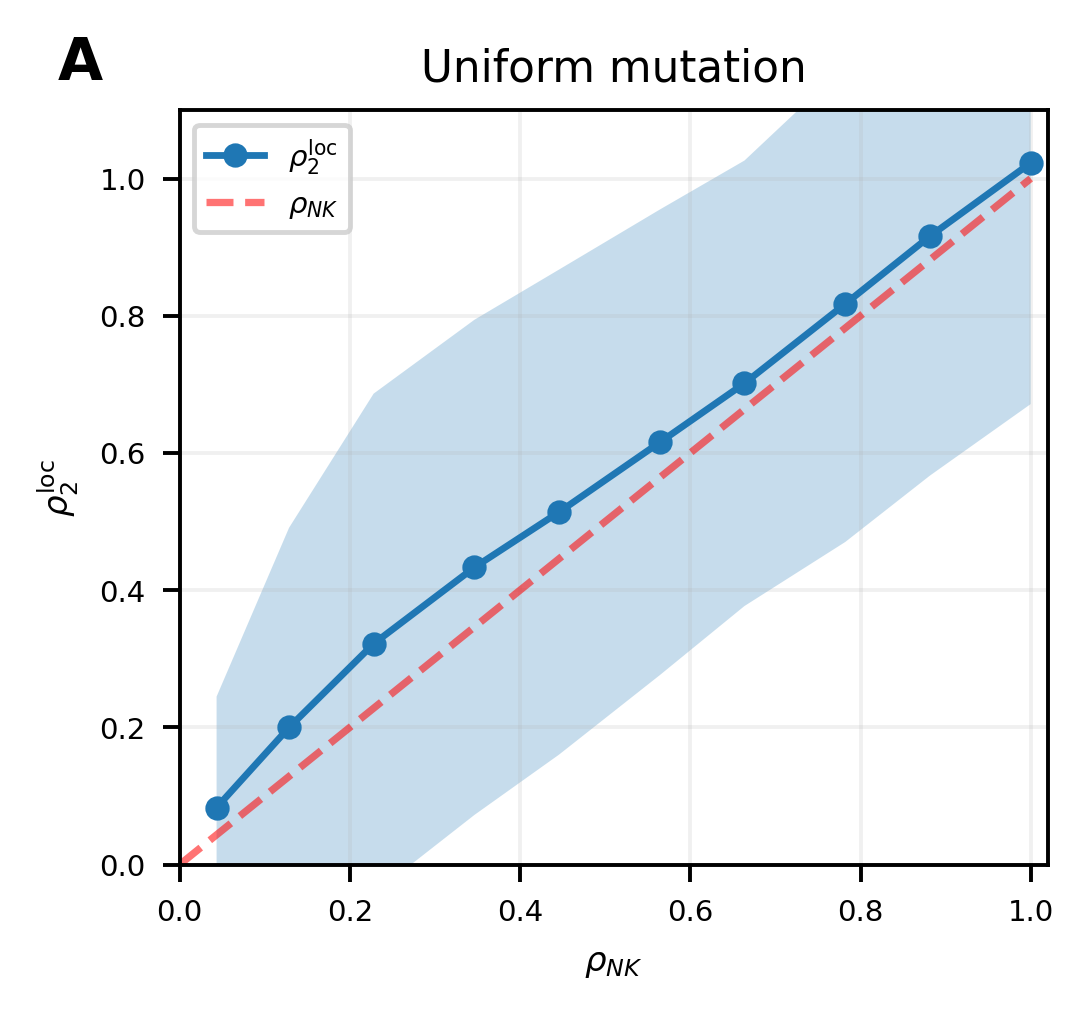

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


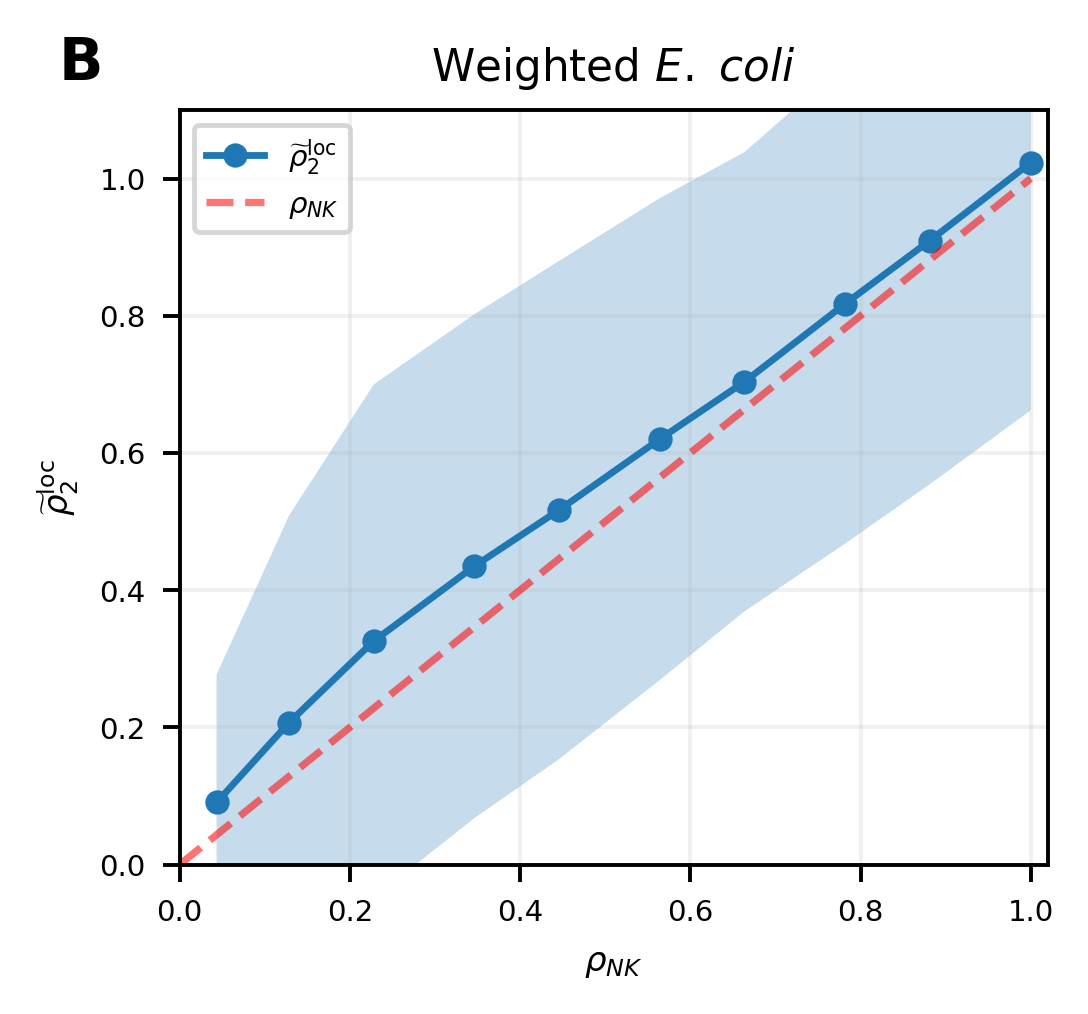

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


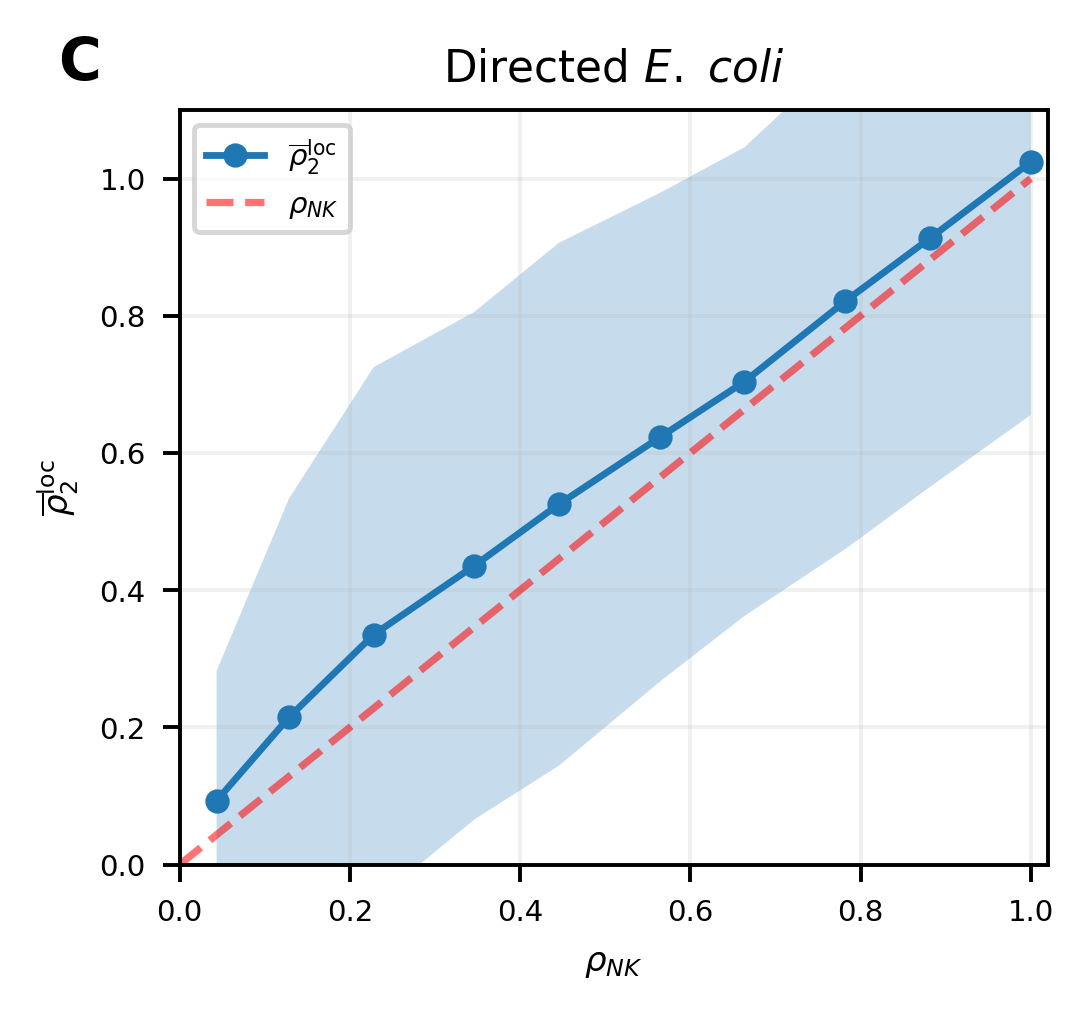

In [40]:
for letter, model in zip("ABC", MODEL_KEYS, strict=True):
    fig, ax = plt.subplots(figsize=(3.2, 2.8), dpi=PANEL_DPI)
    plot_abc_panel(ax, figure6_abc_payload, model)
    add_panel_letter(ax, letter)
    if SAVE_FIGURES:
        save_figure(fig, f"figure_6{letter}")
    plt.show()


## Individual Panels D-F


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


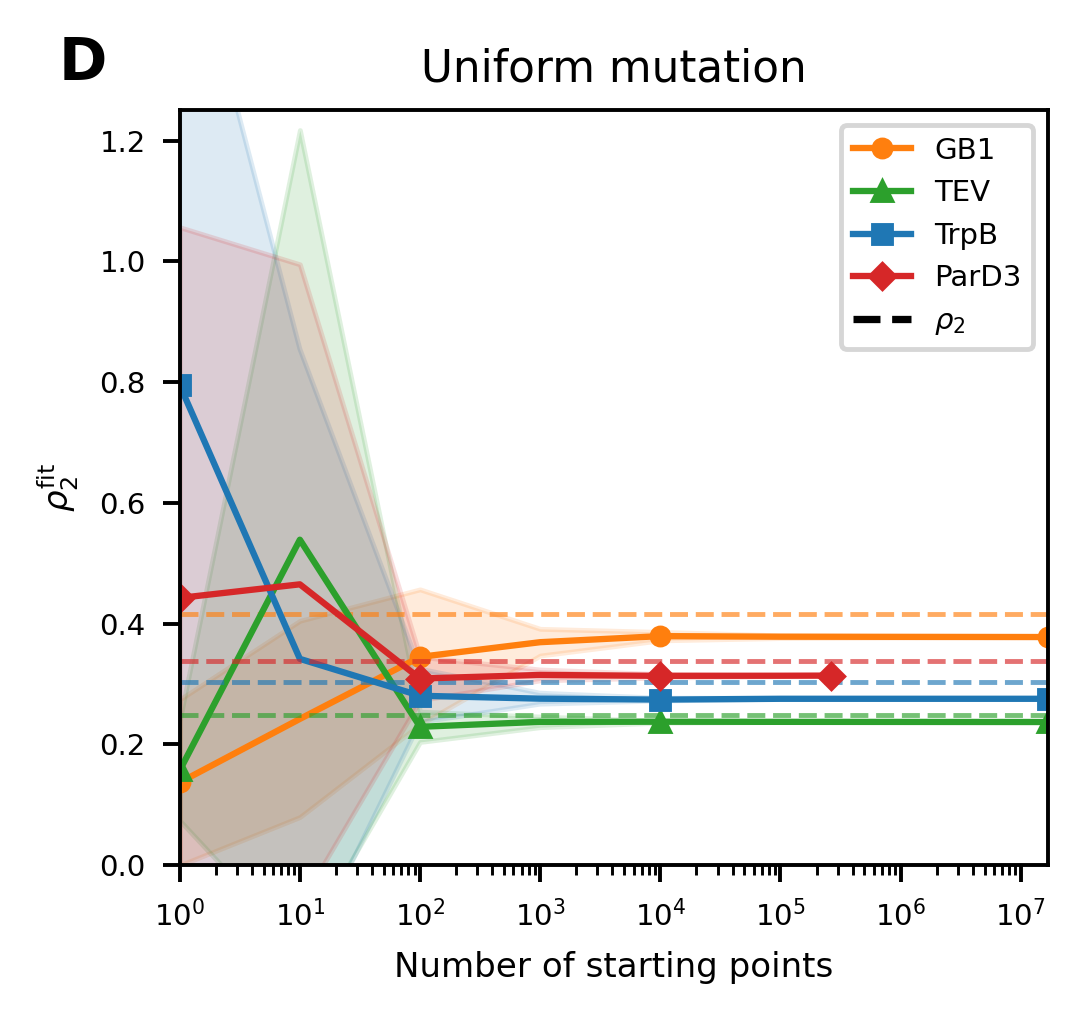

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


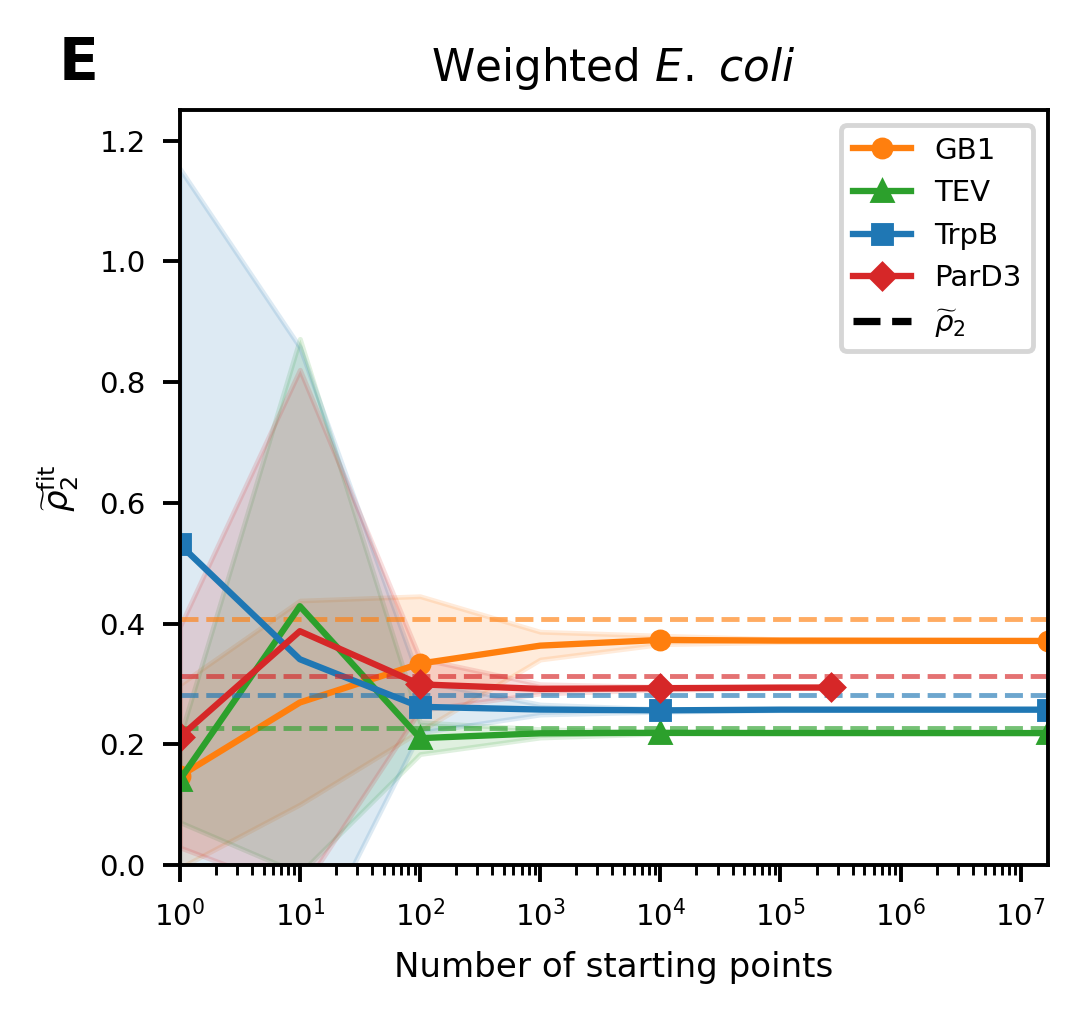

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


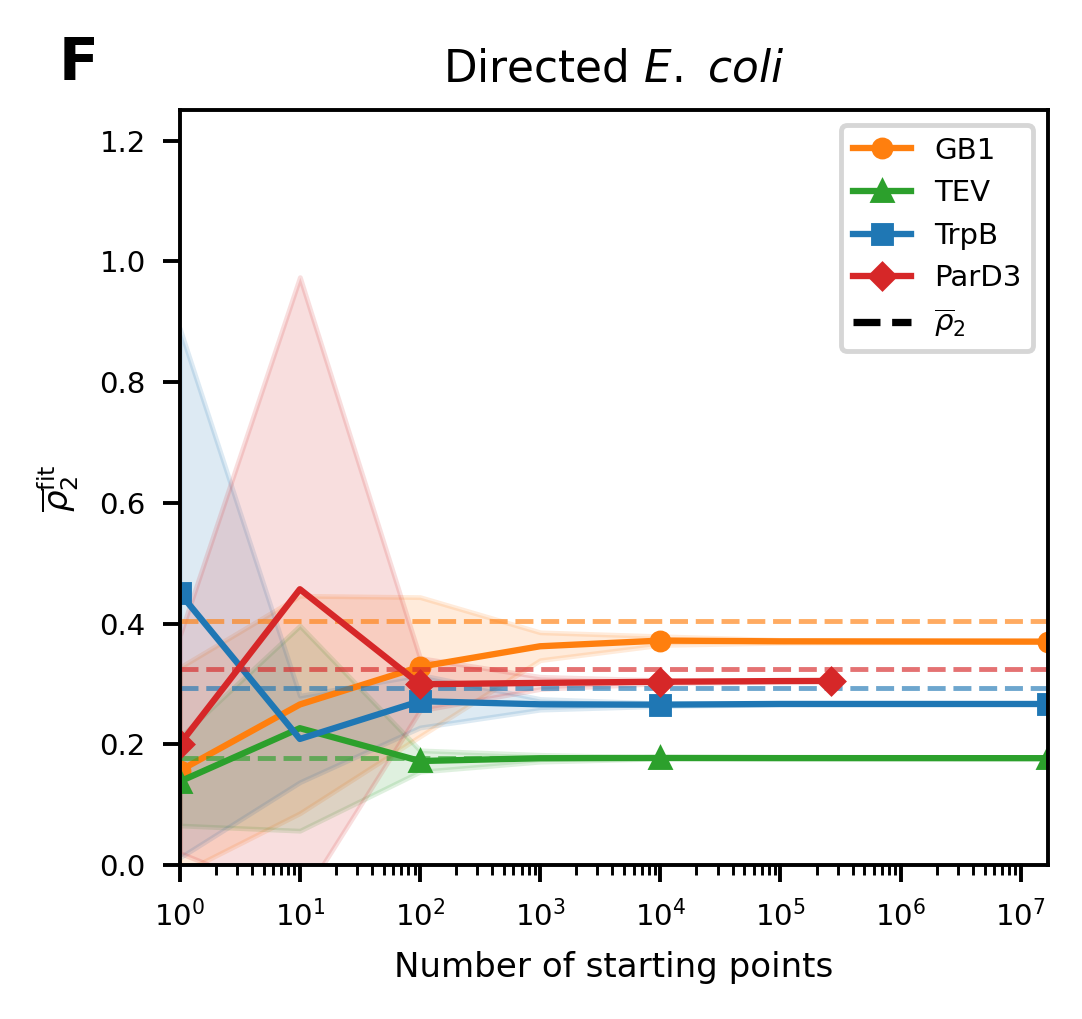

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


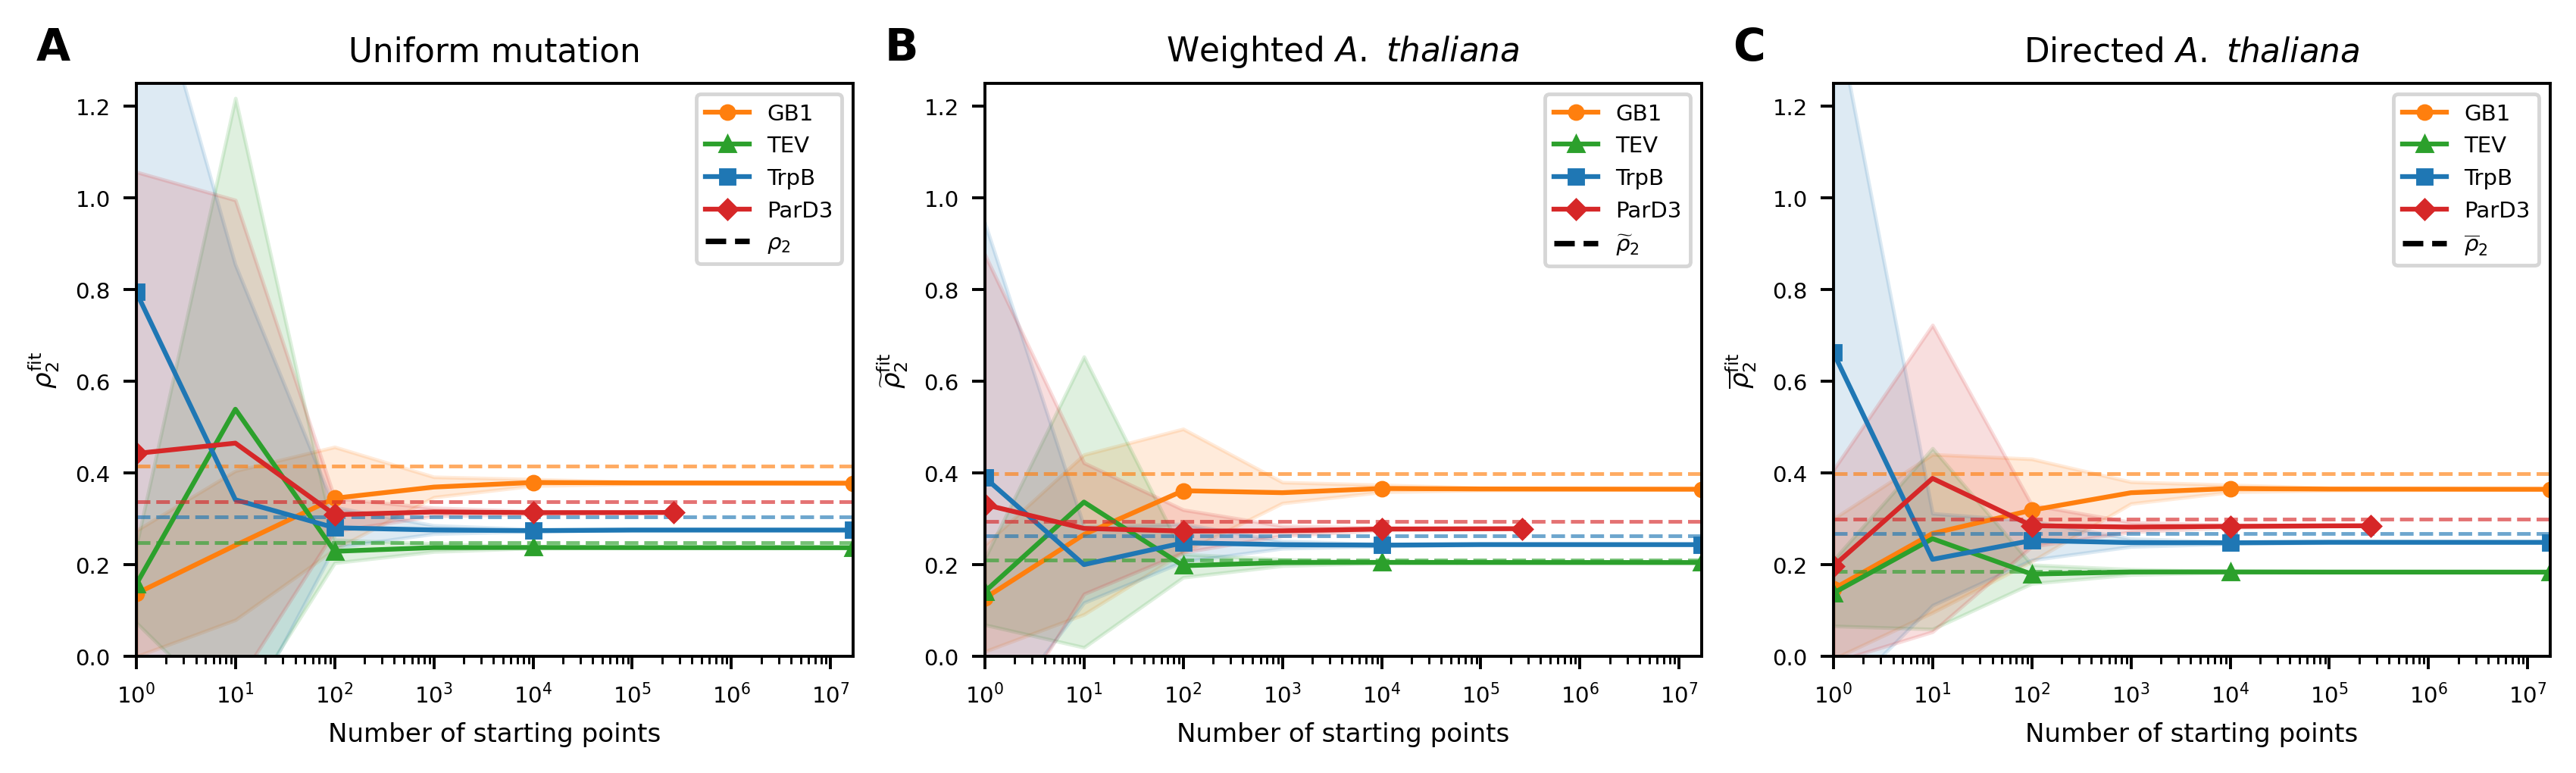

In [41]:
def df_symbol(model: str, *, fitted: bool) -> str:
    """Return the plotted rho_2 symbol for a mutation model.

    Parameters:
    - model: str
        Mutation model key.
    - fitted: bool
        Whether the fitted-rate superscript should be included.

    Returns:
    - str
        Matplotlib mathtext label.
    """
    suffix = r"^{\mathrm{fit}}" if fitted else ""
    if model == "nuc_uniform":
        return rf"$\rho_2{suffix}$"
    if model.endswith("_weighted"):
        return rf"$\widetilde{{\rho}}_2{suffix}$"
    return rf"$\overline{{\rho}}_2{suffix}$"


def plot_df_panel(ax: Axes, payload: dict[str, object], model: str) -> None:
    """Plot sampling accuracy and its analytical reference for one kernel.

    Parameters:
    - ax: Axes
        Axis receiving the plot.
    - payload: dict[str, object]
        Processed D-F full-nucleotide payload.
    - model: str
        Mutation-model key.

    Returns:
    - None
        Artists are added to the axis.
    """
    symbol = df_symbol(model, fitted=True)
    reference_symbol = df_symbol(model, fitted=False)
    max_start_count = 1
    for index, (name, color, marker) in enumerate(zip(
        LANDSCAPE_NAMES, LANDSCAPE_COLORS, LANDSCAPE_MARKERS, strict=True
    )):
        starts = np.asarray(payload["counts"][model][index], dtype=float)
        values = payload["data"][model][index]
        means = np.asarray([np.nanmean(item) for item in values])
        stds = np.asarray([np.nanstd(item, ddof=1) for item in values])
        max_start_count = max(max_start_count, int(np.nanmax(starts)))
        ax.plot(starts, means, color=color, marker=marker, markersize=3.5,
                markevery=2, linewidth=1.3, label=name)
        ax.fill_between(starts, means - stds, means + stds, color=color, alpha=0.15)
        reference = float(figure6_analytics["data"][name][model]["rho_2"])
        ax.axhline(reference, color=color, linestyle="--", linewidth=1.0, alpha=0.65)
    ax.set_xscale("log")
    ax.set_title(MODEL_TITLES[model], fontsize=FIGURE_TITLE_SIZE)
    ax.set_xlabel("Number of starting points", fontsize=FIGURE_LABEL_SIZE)
    ax.set_ylabel(symbol, fontsize=FIGURE_LABEL_SIZE)
    ax.set_xlim(1, max_start_count)
    ax.set_ylim(0, 1.25)
    handles, labels = ax.get_legend_handles_labels()
    handles.append(mlines.Line2D([], [], color="black", linestyle="--", label=reference_symbol))
    labels.append(reference_symbol)
    ax.legend(handles, labels, fontsize=FIGURE_LEGEND_SIZE, loc="upper right")
    ax.tick_params(labelsize=FIGURE_TICK_SIZE)
    

for letter, model in zip("DEF", MODEL_KEYS, strict=True):
    fig, ax = plt.subplots(figsize=(3.2, 2.8), dpi=PANEL_DPI)
    plot_df_panel(ax, figure6_df_payload, model)
    add_panel_letter(ax, letter)
    if SAVE_FIGURES:
        save_figure(fig, f"figure_6{letter}")
    plt.show()


fig, axes = plt.subplots(1, 3, figsize=(9.6, 2.8), dpi=PANEL_DPI, constrained_layout=True)
for ax, letter, model in zip(axes, "ABC", DF_ATHALIANA_MODEL_KEYS, strict=True):
    plot_df_panel(ax, figure6_a_thaliana_df_payload, model)
    add_panel_letter(ax, letter)
if SAVE_FIGURES:
    save_figure(fig, "figure_6_a_thaliana_df")
plt.show()


## Individual Panels G--H

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


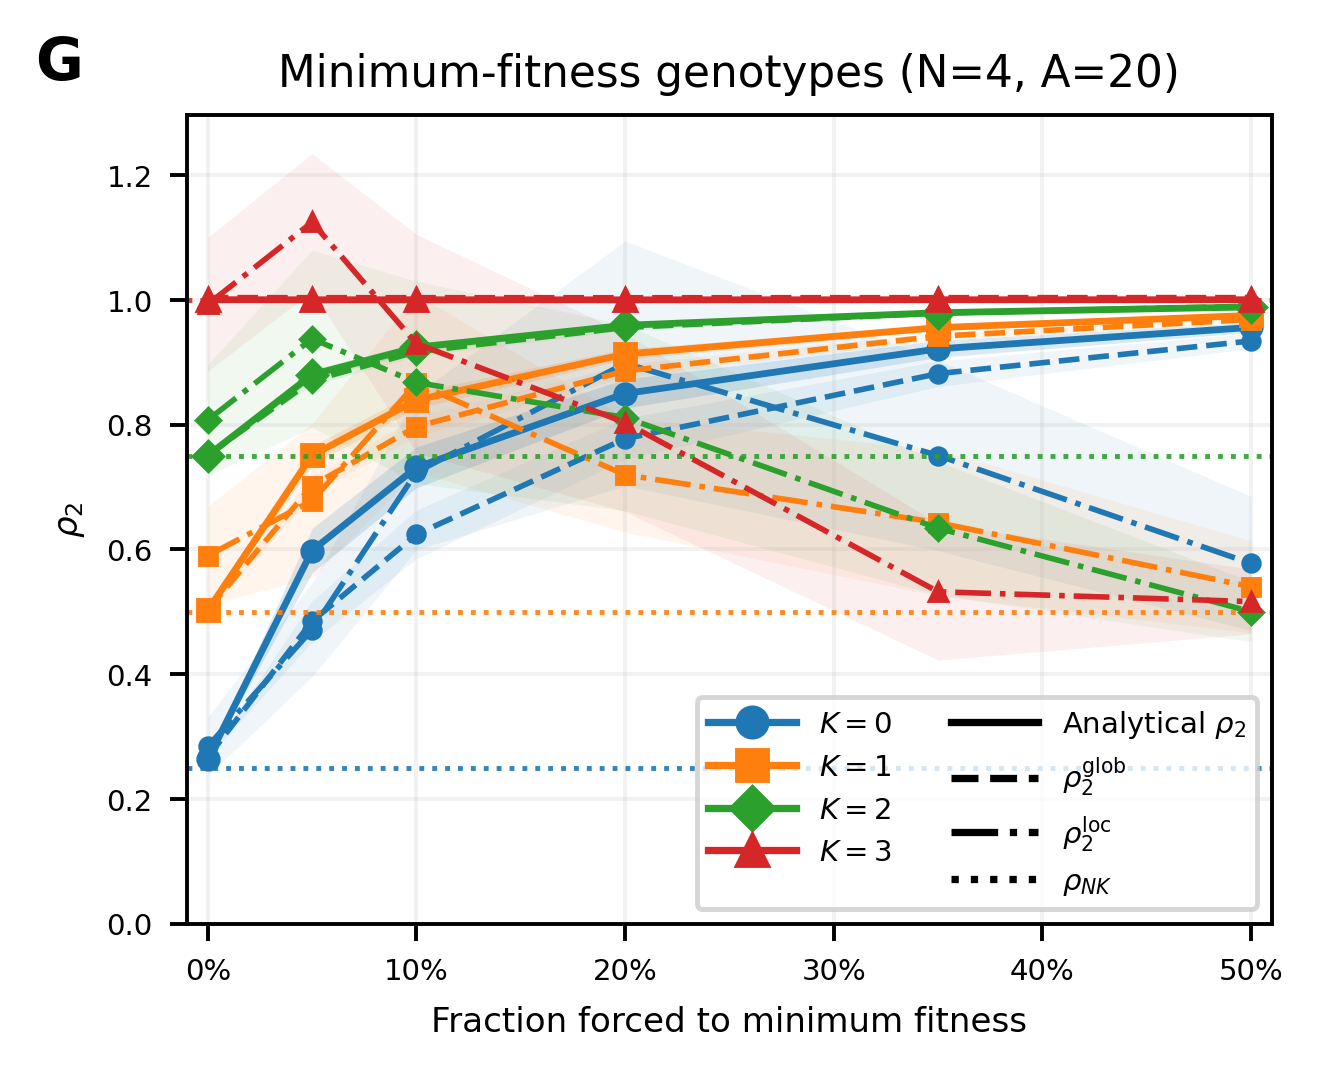

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


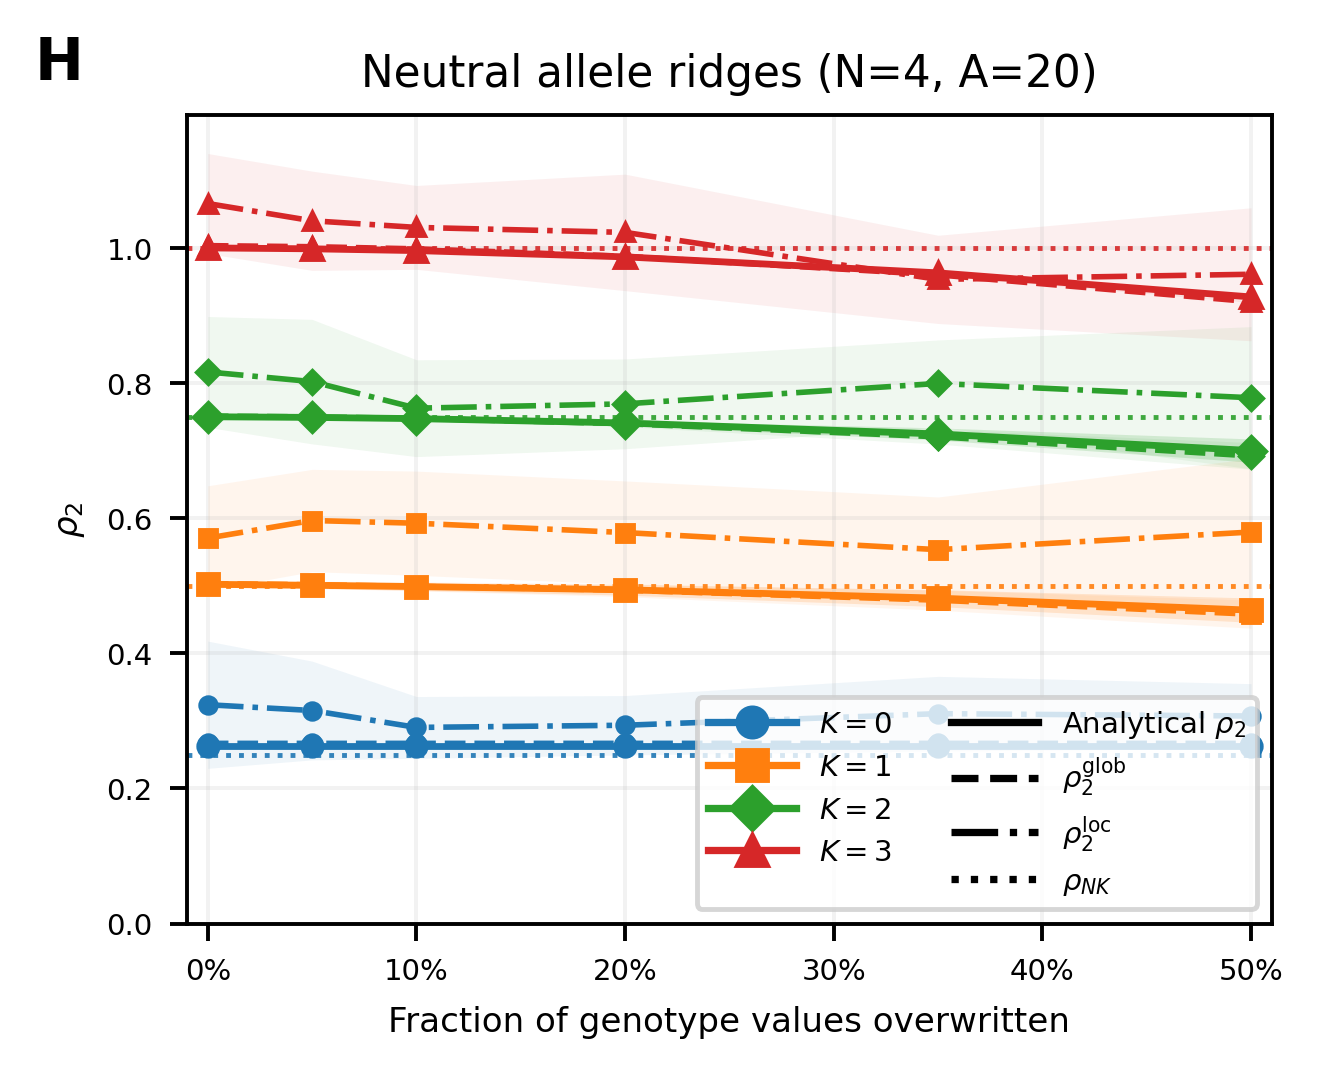

In [42]:

def plot_figure6_new_rho2_panel(
    ax: Axes,
    payload: dict[str, object],
    decay_payload: dict[str, object],
    perturbation: str,
) -> None:
    """Plot analytical rho_2 against a controlled landscape perturbation.

    Parameters:
    - ax: Axes
        Axis receiving the plot.
    - payload: dict[str, object]
        Processed lethal-node and neutral-ridge results.
    - decay_payload: dict[str, object]
        Processed global and local fitted decay rates.
    - perturbation: str
        Either ``lethal`` or ``neutral``.

    Returns:
    - None
        Plot artists are added directly to ``ax``.
    """
    if perturbation not in {"lethal", "neutral"}:
        raise ValueError("perturbation must be 'lethal' or 'neutral'.")
    data = payload["data"]
    params = payload["params"]
    fractions = np.asarray(data["fractions"], dtype=float)
    means = np.asarray(data[f"{perturbation}_mean"], dtype=float)
    standard_deviations = np.asarray(data[f"{perturbation}_std"], dtype=float)
    decay_data = decay_payload["data"]
    perturbation_index = PERTURBATIONS.index(perturbation)
    global_means = np.asarray(decay_data["global_mean"], dtype=float)[perturbation_index]
    global_stds = np.asarray(decay_data["global_std"], dtype=float)[perturbation_index]
    local_means = np.asarray(decay_data["local_mean"], dtype=float)[perturbation_index]
    local_stds = np.asarray(decay_data["local_std"], dtype=float)[perturbation_index]
    k_values = tuple(int(value) for value in params["K_values"])
    n_sites = int(params["N"])
    colors = ("tab:blue", "tab:orange", "tab:green", "tab:red")
    markers = ("o", "s", "D", "^")

    for k_index, k_value in enumerate(k_values):
        color = colors[k_index]
        ax.plot(
            fractions,
            means[k_index],
            color=color,
            marker=markers[k_index],
            linewidth=1.4,
            markersize=4,
            label=rf"$K={k_value}$",
        )
        ax.fill_between(
            fractions,
            means[k_index] - standard_deviations[k_index],
            means[k_index] + standard_deviations[k_index],
            color=color,
            alpha=0.16,
            linewidth=0,
        )
        fitted_series = (
            (global_means[k_index], global_stds[k_index], "--"),
            (local_means[k_index], local_stds[k_index], "-."),
        )
        for fitted_mean, fitted_std, line_style in fitted_series:
            ax.plot(
                fractions, fitted_mean, color=color, marker=markers[k_index],
                linestyle=line_style, linewidth=1.15, markersize=3.2,
            )
            ax.fill_between(
                fractions, fitted_mean - fitted_std, fitted_mean + fitted_std,
                color=color, alpha=0.07, linewidth=0,
            )
        ax.axhline(
            (k_value + 1) / n_sites,
            color=color,
            linestyle=":",
            linewidth=1.0,
            alpha=0.9,
        )

    k_handles = [
        mlines.Line2D([], [], color=colors[index], marker=markers[index],
                      linestyle="-", label=rf"$K={k_value}$")
        for index, k_value in enumerate(k_values)
    ]
    estimator_handles = [
        mlines.Line2D([], [], color="black", linestyle="-", label=r"Analytical $\rho_2$"),
        mlines.Line2D([], [], color="black", linestyle="--", label=r"$\rho_2^{\mathrm{glob}}$"),
        mlines.Line2D([], [], color="black", linestyle="-.", label=r"$\rho_2^{\mathrm{loc}}$"),
        mlines.Line2D([], [], color="black", linestyle=":", label=r"$\rho_{NK}$"),
    ]
    ax.legend(
        handles=k_handles + estimator_handles,
        fontsize=FIGURE_LEGEND_SIZE,
        ncol=2,
        frameon=True,
        loc="lower right",
        handlelength=3.0,
    )
    if perturbation == "lethal":
        ax.set_title(rf"Minimum-fitness genotypes (N={N_SITES}, A={NUM_ALLELES})", fontsize=FIGURE_TITLE_SIZE)
        ax.set_xlabel("Fraction forced to minimum fitness", fontsize=FIGURE_LABEL_SIZE)
    else:
        ax.set_title(rf"Neutral allele ridges (N={N_SITES}, A={NUM_ALLELES})", fontsize=FIGURE_TITLE_SIZE)
        ax.set_xlabel("Fraction of genotype values overwritten", fontsize=FIGURE_LABEL_SIZE)
    ax.set_ylabel(r"$\rho_2$", fontsize=FIGURE_LABEL_SIZE)
    ax.set_xlim(-0.01, 0.51)
    upper_limit = 1.05 * max(
        1.10,
        float(np.nanmax(means + standard_deviations)),
        float(np.nanmax(global_means + global_stds)),
        float(np.nanmax(local_means + local_stds)),
    )
    ax.set_ylim(0.0, upper_limit)
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    ax.tick_params(labelsize=FIGURE_TICK_SIZE)
    ax.grid(True, alpha=0.16)

for letter, perturbation in zip("GH", ("lethal", "neutral"), strict=True):
    fig, ax = plt.subplots(figsize=(4.0, 3.0), dpi=PANEL_DPI)
    plot_figure6_new_rho2_panel(
        ax, figure6_new_payload, figure6_decay_processed, perturbation
    )
    add_panel_letter(ax, letter)
    if SAVE_FIGURES:
        save_figure(fig, f"figure_6{letter}")
    plt.show()


## Individual Panel I


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


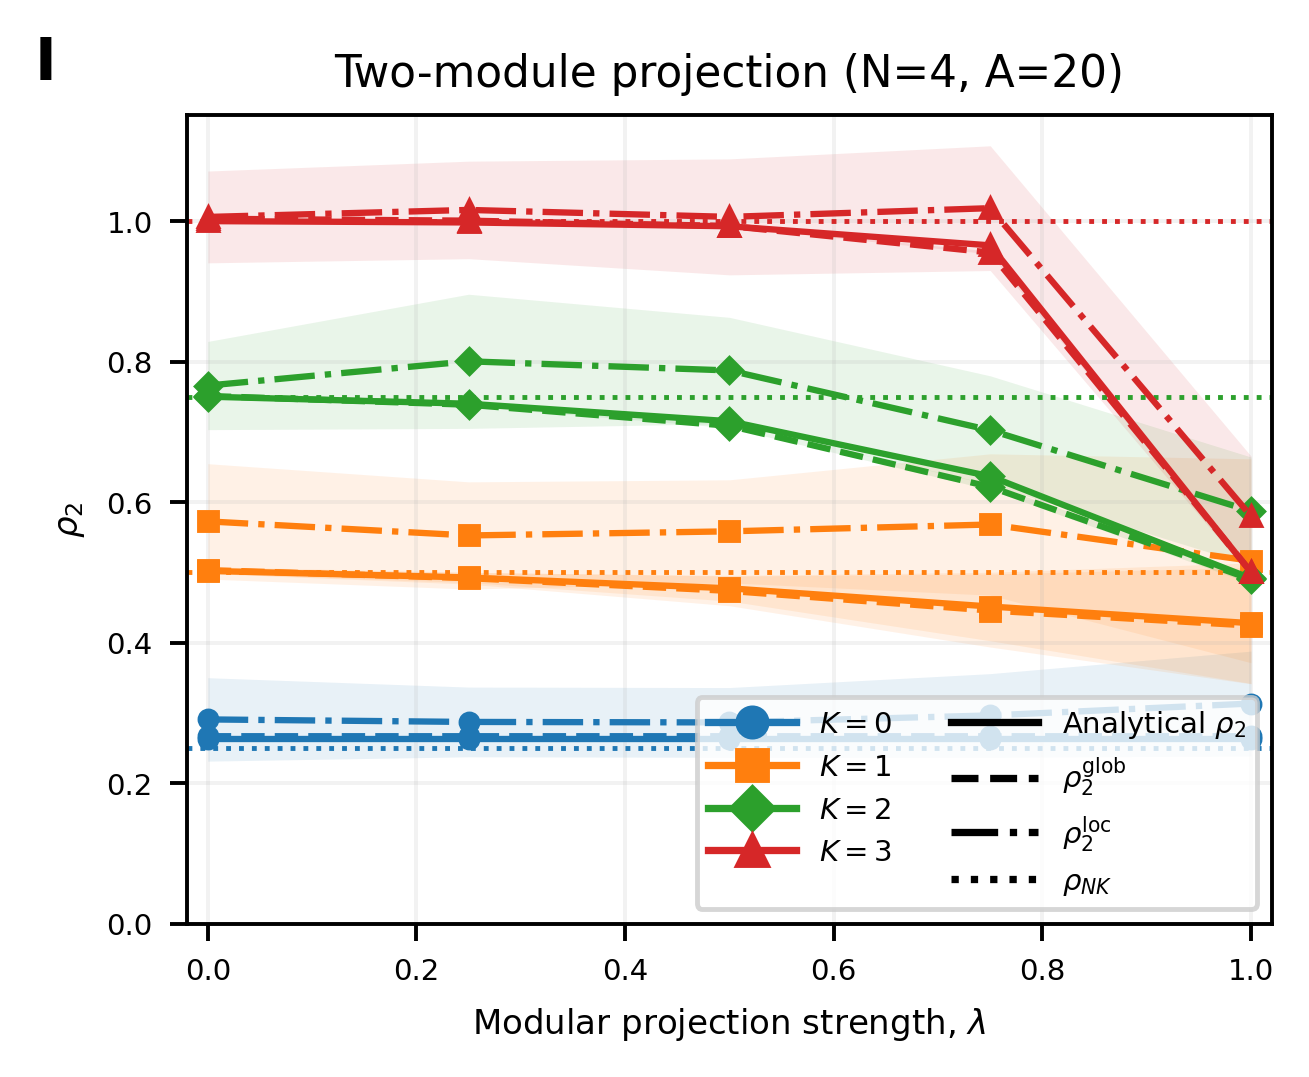

In [43]:
def plot_modularity_panel(ax: Axes) -> None:
    """Plot analytical, global, and local Figure 6I estimates.

    Parameters:
    - ax: Axes
        Target axes.

    Returns:
    - None
        Artists are added in place.
    """
    analytical = figure6_i_analytical["data"]
    fitted = figure6_i_fitted["data"]
    lambdas = np.asarray(I_LAMBDA_VALUES)
    colors = ("tab:blue", "tab:orange", "tab:green", "tab:red")
    markers = ("o", "s", "D", "^")
    for index, k_value in enumerate(I_K_VALUES):
        for mean_key, std_key, style in (
            ("mean", "std", "-"),
            ("global_mean", "global_std", "--"),
            ("local_mean", "local_std", "-."),
        ):
            source = analytical if mean_key == "mean" else fitted
            mean = np.asarray(source[mean_key])[index]
            std = np.asarray(source[std_key])[index]
            ax.plot(
                lambdas, mean, color=colors[index], marker=markers[index],
                linestyle=style, linewidth=1.3, markersize=3.5,
            )
            ax.fill_between(
                lambdas, mean - std, mean + std,
                color=colors[index], alpha=0.10, linewidth=0,
            )
        ax.axhline((k_value + 1) / I_N_SITES, color=colors[index], linestyle=":", linewidth=1.0)
    k_handles = [
        mlines.Line2D([], [], color=colors[index], marker=markers[index], label=rf"$K={k_value}$")
        for index, k_value in enumerate(I_K_VALUES)
    ]
    estimator_handles = [
        mlines.Line2D([], [], color="black", linestyle=style, label=label)
        for style, label in (
            ("-", r"Analytical $\rho_2$"),
            ("--", r"$\rho_2^{\mathrm{glob}}$"),
            ("-.", r"$\rho_2^{\mathrm{loc}}$"),
            (":", r"$\rho_{NK}$"),
        )
    ]
    ax.legend(
        handles=k_handles + estimator_handles,
        ncol=2,
        fontsize=FIGURE_LEGEND_SIZE,
        loc="lower right",
        handlelength=3.0,
    )
    ax.set_title(rf"Two-module projection (N={I_N_SITES}, A={I_NUM_ALLELES})", fontsize=FIGURE_TITLE_SIZE)
    ax.set_xlabel(r"Modular projection strength, $\lambda$", fontsize=FIGURE_LABEL_SIZE)
    ax.set_ylabel(r"$\rho_2$", fontsize=FIGURE_LABEL_SIZE)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=FIGURE_TICK_SIZE)
    ax.grid(True, alpha=0.16)


fig, ax = plt.subplots(figsize=(4.0, 3.0), dpi=PANEL_DPI)
plot_modularity_panel(ax)
add_panel_letter(ax, "I")
if SAVE_FIGURES:
    save_figure(fig, "figure_6I")
plt.show()


## Complete Figure 6 New A-I


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


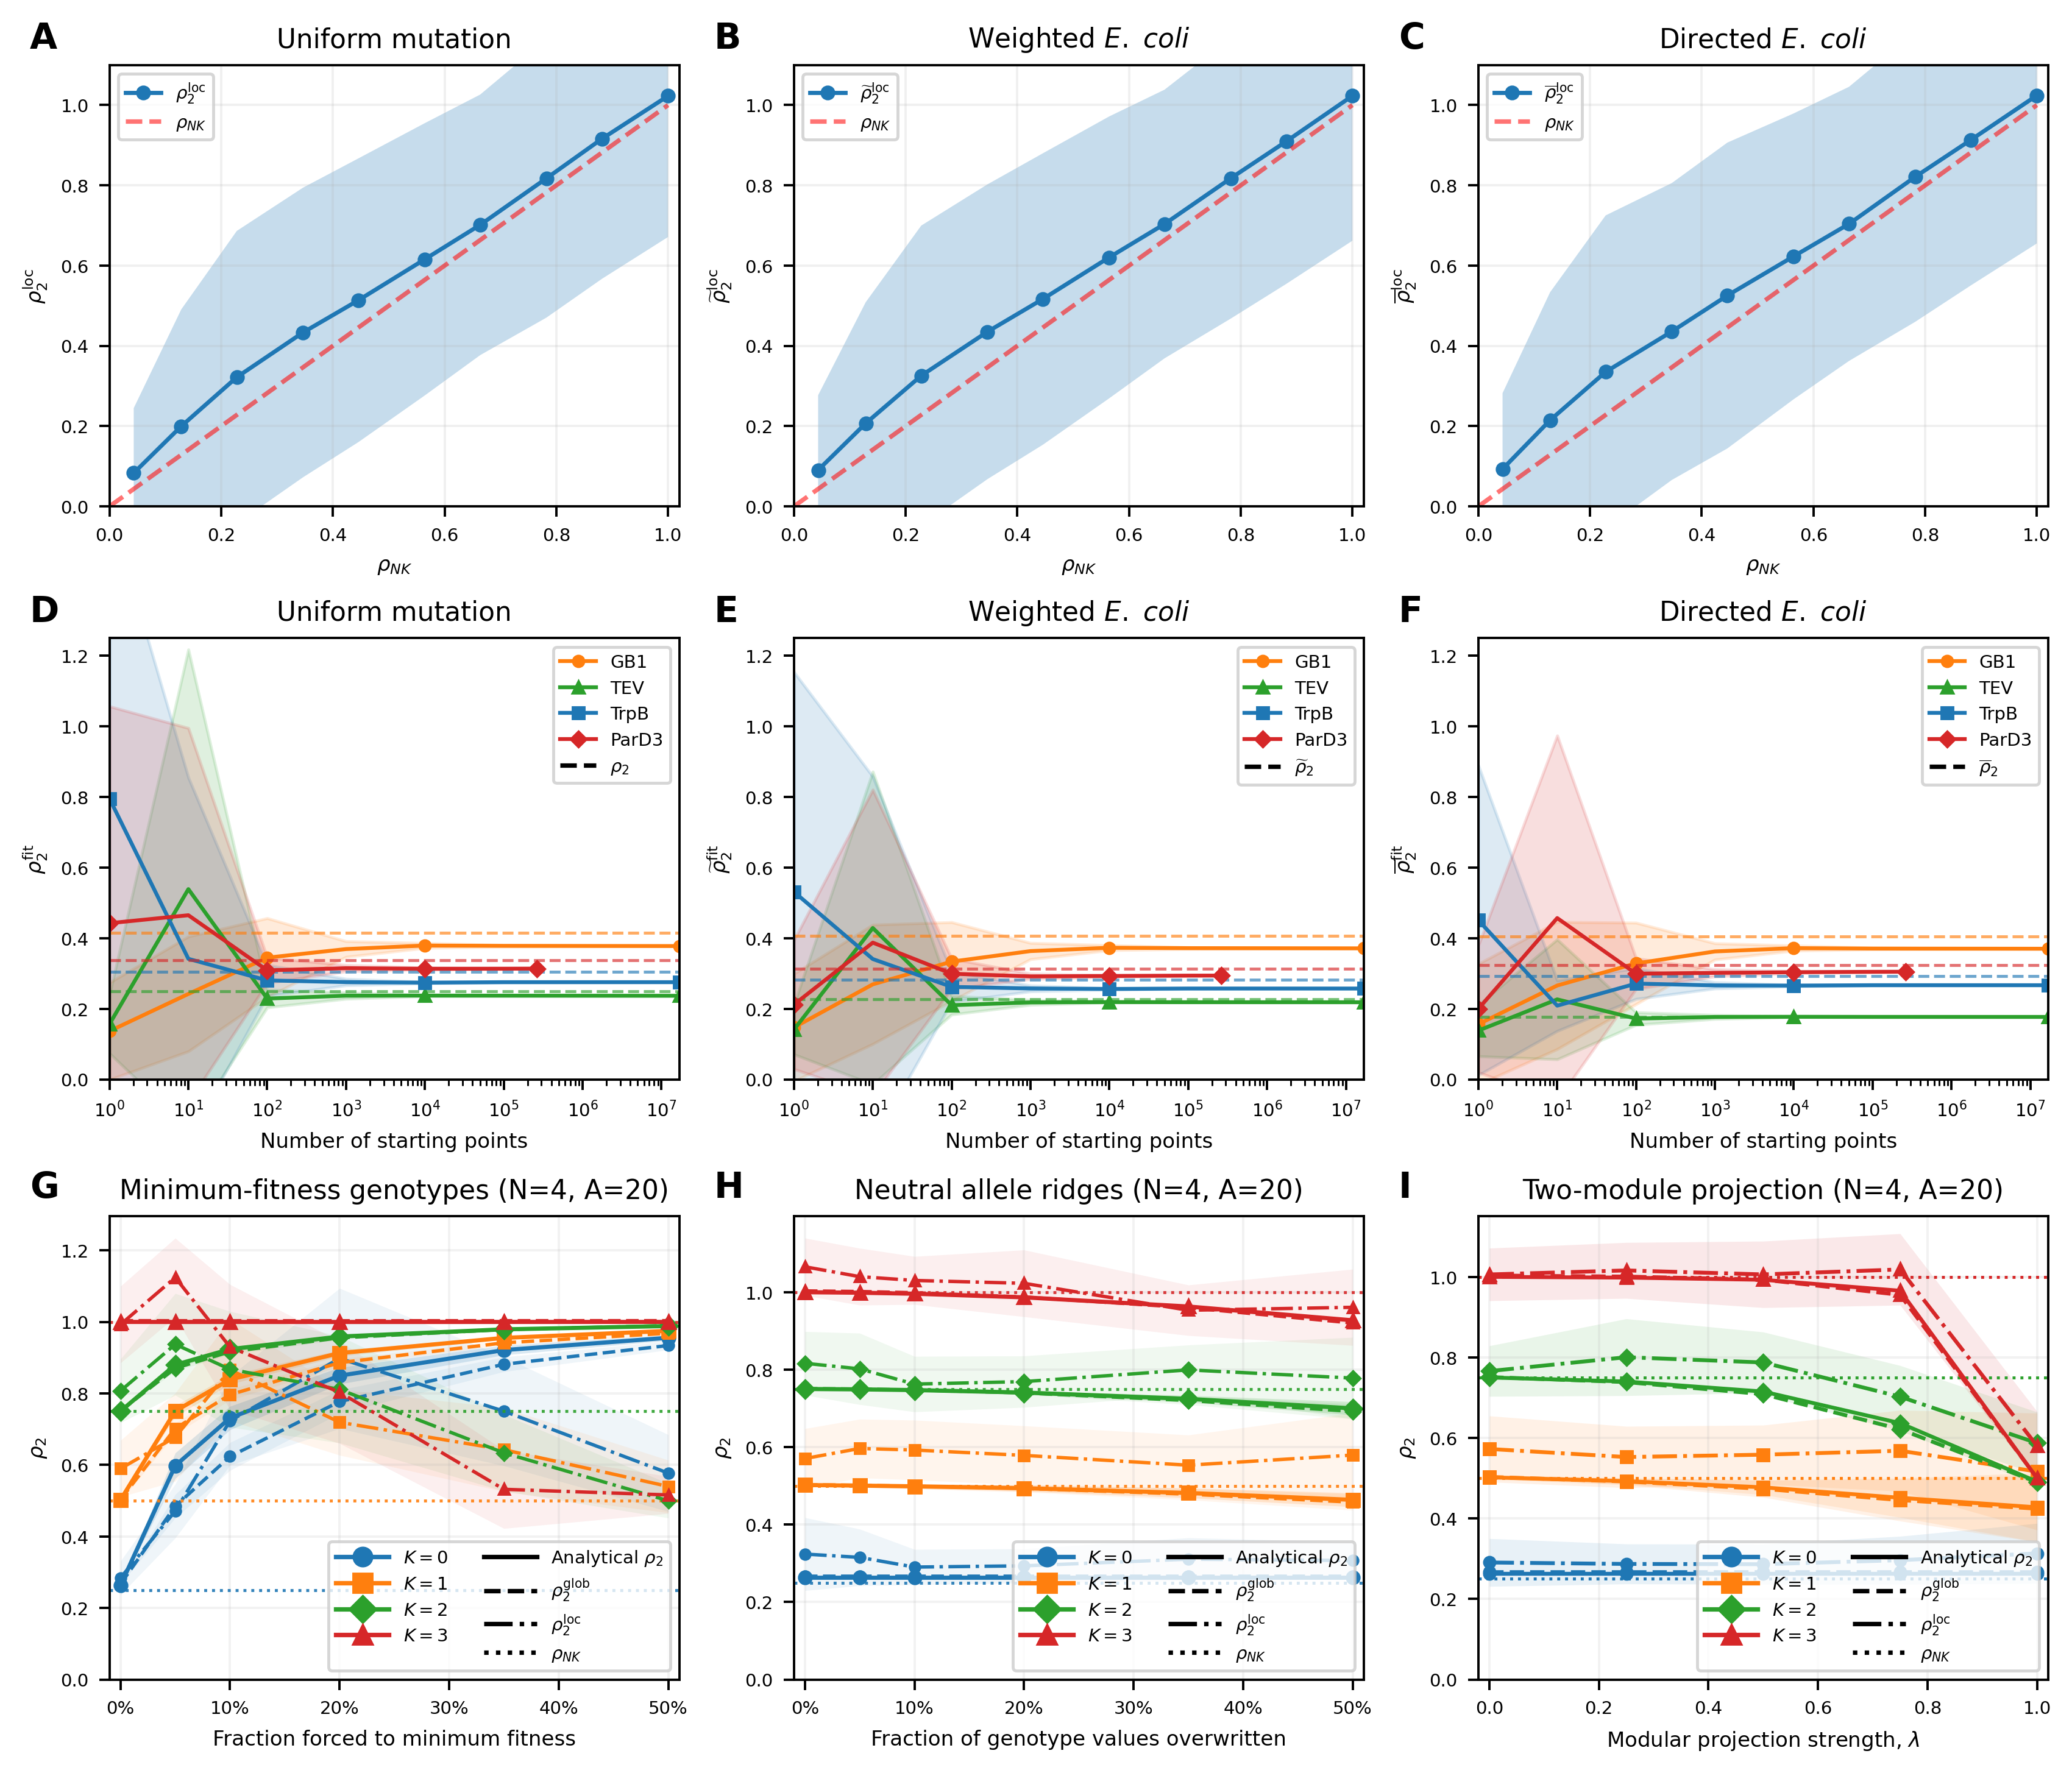

In [44]:
fig = plt.figure(figsize=(9.6, 8.2), dpi=PANEL_DPI, constrained_layout=True)
grid = GridSpec(3, 6, figure=fig, height_ratios=[1.0, 1.0, 1.05])

abc_axes = [fig.add_subplot(grid[0, 2 * column:2 * column + 2]) for column in range(3)]
for ax, letter, model in zip(abc_axes, "ABC", MODEL_KEYS, strict=True):
    plot_abc_panel(ax, figure6_abc_payload, model)
    add_panel_letter(ax, letter)

df_axes = [fig.add_subplot(grid[1, 2 * column:2 * column + 2]) for column in range(3)]
for ax, letter, model in zip(df_axes, "DEF", MODEL_KEYS, strict=True):
    plot_df_panel(ax, figure6_df_payload, model)
    add_panel_letter(ax, letter)

bottom_axes = [fig.add_subplot(grid[2, 2 * column:2 * column + 2]) for column in range(3)]
for ax, letter, perturbation in zip(bottom_axes[:2], "GH", ("lethal", "neutral"), strict=True):
    plot_figure6_new_rho2_panel(ax, figure6_new_payload, figure6_decay_processed, perturbation)
    add_panel_letter(ax, letter)
plot_modularity_panel(bottom_axes[2])
add_panel_letter(bottom_axes[2], "I")

if SAVE_FIGURES:
    save_figure(fig, "figure_6")
plt.show()
